# Clasificación con redes neuronales

En este notebook simple usaremos una FCNN (completamente conectada) para resolver el problema de clasificación de ID de partículas, visto previamente para SVMs.

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
#librerías
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.utils import shuffle

In [3]:
#configuración plot
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 150)

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14)
matplotlib.rc('ytick', labelsize=14)
matplotlib.rcParams['figure.dpi'] = 300

### Librerías para Deep Learning

[Tensorflow](https://www.tensorflow.org/?hl=es-419) es una biblioteca de uso muy común para el desarrollo de modelos de aprendizaje profundo. Es una plataforma de código abierto desarrollada por Google. Admite programación en varios lenguajes, como C++, Java, Python, y muchos otros.

[Keras](https://keras.io/) es una API de alto nivel (Application Programming Interface) construida sobre TensorFlow (o Theano, otra biblioteca de aprendizaje profundo). Es específica para Python, y podemos pensar en ella como el equivalente de la biblioteca sklearn, pero para redes neuronales. Es menos general y menos personalizable, pero muy fácil de usar y comparativamente más sencilla que TensorFlow.

[PyTorch](https://pytorch.org/) es otra biblioteca muy popular para el desarrollo de modelos de aprendizaje profundo, desarrollada por Meta (Facebook). A diferencia de Keras, no es una API de alto nivel sobre otra biblioteca, sino un framework completo en sí mismo. Es especialmente popular en investigación por su flexibilidad para construir arquitecturas no estándar, aunque eso viene con una curva de aprendizaje más pronunciada y bastante más código para tareas simples.

En este curso usaremos Keras con TensorFlow como back-end, porque para los problemas que veremos su simplicidad tiene más peso que la flexibilidad extra de PyTorch.

**Comparación**

| | TensorFlow | Keras | PyTorch |
|---|---|---|---|
| **Qué es** | Framework completo | API de alto nivel (sobre TensorFlow) | Framework completo |
| **Desarrollado por** | Google | Ahora integrado a TensorFlow | Meta (Facebook) |
| **Curva de aprendizaje** | Media-alta | Baja | Media-alta |
| **Líneas de código para un modelo simple** | Muchas | Pocas | Muchas |
| **Flexibilidad para arquitecturas no estándar** | Alta | Media | Muy alta |
| **Dónde se usa más** | Producción, industria | Prototipado rápido, docencia | Investigación, papers recientes |


In [4]:
import sys
print(sys.version)

3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]


In [5]:
#!pip install tensorflow

In [6]:
import tensorflow as tf

I0000 00:00:1785991669.084033   26652 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785991670.775213   26652 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785991674.111752   26652 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [7]:
tf.__version__

'2.21.0'

Importamos `keras` y usaremos `Sequential`, que admite una entrada y una salida

In [8]:
import keras

from keras.models import Sequential # El modelo se construye agregando una capa después de otra

from keras.layers import Dense #totalmente conectadas: cada output se conecta con cada input

from keras.layers import Dropout #para regularización

Comenzamos con el problema de 4top vs ttbar, y utilizamos la configuración en la que añadimos las características "número de leptones", "número de jets", etc. Como referencia, el SVM óptimo alcanzó un 94-95% de precisión. Cabe destacar que esos números no se obtuvieron utilizando validación cruzada anidada, por lo que podrían ser ligeramente optimistas.

In [9]:
X = pd.read_csv('Features_lim_2.csv') # partículas 

In [10]:
y = np.genfromtxt('Labels_lim_2.txt') # labels

In [11]:
X.values.shape

(5000, 24)

In [12]:
X.head() # header

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
0,0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800,5,1,3,0,1
1,1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630,4,0,2,0,2
2,2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690,5,1,4,0,0
3,3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631,5,1,4,0,0
4,4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381,5,0,5,0,0


In [13]:
y

array([0., 0., 0., ..., 0., 1., 0.])

Aquí no hay un proceso de validación cruzada "integrado", por lo que tendríamos que implementarlo nosotros mismos. Por ahora, podemos construir tres conjuntos: entrenamiento, validación (para la optimización de parámetros) y prueba (para la evaluación final). Idealmente, deberíamos estructurarlo como una validación cruzada.

En la práctica, rara vez se hace CV k-fold completa con redes neuronales. Cada fold implica reentrenar la red desde cero, así que el costo computacional escala rápido: con 5 folds ya estamos pagando 5 veces el costo de entrenamiento, y eso antes de siquiera empezar a buscar hiperparámetros. Además, la razón principal para usar CV es obtener una estimación confiable del desempeño cuando el dataset es chico; con datasets grandes (el escenario típico donde las NN funcionan mejor), un solo split bien hecho ya da una estimación razonablemente estable.

Por eso optamos por un split fijo train/validación/prueba, y usamos el set de validación para *early stopping* y ajuste de hiperparámetros. Esto evita el costo de CV sin sacrificar demasiado rigor.

#### Sets de entrenamiento y prueba

Este dataset tiene un desbalance importante entre las dos clases. Para que esa proporción se mantenga en cada split, usamos `stratify` al dividir los datos.

In [14]:
clase, total = np.unique(y, return_counts=True)
print(dict(zip(clase, total))) # 4top vs ttbar

{0.0: 4189, 1.0: 811}


In [15]:
razon = total[1] / total[0]
print(f"Razón: {razon:.2f}")

Razón: 0.19


In [16]:
# Primero separamos test (20%), estratificado por clase
X_temp, X_test, y_temp, y_test = train_test_split(
    X.values, y, test_size=0.2, stratify=y, random_state=10 # stratify para mantener separación entre clases 
)

# Del resto, separamos train/val (80/20 de lo que queda)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=10
)

print(X_train.shape, X_val.shape, X_test.shape)
print("Balance train:", y_train.mean(), "| val:", y_val.mean(), "| test:", y_test.mean())

(3200, 24) (800, 24) (1000, 24)
Balance train: 0.1621875 | val: 0.1625 | test: 0.162


### Construyendo la red

Pensemos en la arquitectura del modelo.

Nuestra capa de entrada tiene **24 neuronas** (24 características)

Nuestra capa de salida tiene **una neurona** (la salida es la probabilidad de que el objeto pertenezca a la clase positiva). También podríamos configurarla con dos neuronas (y usar softmax como la no linealidad final), pero esto es redundante en un problema de clasificación binaria. La neurona de salida será una función **sigmoide**

Añadiremos **dos capas ocultas**. En este caso, ambas tienen tamaño = 20 (debemos optimizar este hiperparámetro!). También podemos reservar la posibilidad de añadir una capa de dropout después de cada una.

Otras decisiones que debemos tomar son: qué no linealidades usar (por ahora: ReLU para las capas ocultas, sigmoide para la final), qué optimizador usar (Adam), qué tasa de aprendizaje inicial adoptar (aquí 0.001, aunque nuevamente esto debería decidirse mediante CV), el número de épocas (por ejemplo, 100; podemos graficar cantidades de interés para verificar que esto sea suficiente), el tamaño de lote (batch size) para el paso de descenso por gradiente (aquí 200, pero podemos explorarlo!) y la función de pérdida. Esta última es la entropía cruzada binaria ([binary cross entropy](https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a)), que es la elección estándar para problemas de clasificación donde la salida es una probabilidad. Premia la "confianza" en una predicción correcta (alta probabilidad).

El siguiente comando nos ayuda a explorar todas las posibles opciones

In [17]:
dir(keras.optimizers)

['Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'Ftrl',
 'Lamb',
 'Lion',
 'LossScaleOptimizer',
 'Muon',
 'Nadam',
 'Optimizer',
 'RMSprop',
 'SGD',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'deserialize',
 'get',
 'legacy',
 'schedules',
 'serialize']

In [18]:
dir(keras.losses)

['BinaryCrossentropy',
 'BinaryFocalCrossentropy',
 'CTC',
 'CategoricalCrossentropy',
 'CategoricalFocalCrossentropy',
 'CategoricalGeneralizedCrossEntropy',
 'CategoricalHinge',
 'Circle',
 'CosineSimilarity',
 'Dice',
 'Hinge',
 'Huber',
 'KLDivergence',
 'LogCosh',
 'Loss',
 'MeanAbsoluteError',
 'MeanAbsolutePercentageError',
 'MeanSquaredError',
 'MeanSquaredLogarithmicError',
 'Poisson',
 'SparseCategoricalCrossentropy',
 'SquaredHinge',
 'Tversky',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'binary_crossentropy',
 'binary_focal_crossentropy',
 'categorical_crossentropy',
 'categorical_focal_crossentropy',
 'categorical_generalized_cross_entropy',
 'categorical_hinge',
 'circle',
 'cosine_similarity',
 'ctc',
 'deserialize',
 'dice',
 'get',
 'hinge',
 'huber',
 'kl_divergence',
 'log_cosh',
 'mean_absolute_error',
 'mean_absolute_percentage_error',
 'mean_squared_error',
 'mean_squared_logarith

La opción estándar para un caso como el nuestro, donde las etiquetas son 0/1, pero podemos predecir una probabilidad, es binary cross-entropy or log loss:

L = - $\frac{1}{N} \sum_{i=1}^N y_i \cdot log(p(y_i)) + (1-y_i) \cdot log (1 - p(y_i))$

$p$ es la probabilidad de que un objeto pertenezca a la clase positiva. Penaliza los ejemplos positivos que están asociados con una probabilidad predicha baja, y los ejemplos negativos que están asociados con una probabilidad predicha alta.


Acá una lista de funciones de activación

In [19]:
dir(keras.activations)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'celu',
 'deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'glu',
 'hard_shrink',
 'hard_sigmoid',
 'hard_silu',
 'hard_swish',
 'hard_tanh',
 'leaky_relu',
 'linear',
 'log_sigmoid',
 'log_softmax',
 'mish',
 'relu',
 'relu6',
 'selu',
 'serialize',
 'sigmoid',
 'silu',
 'soft_shrink',
 'softmax',
 'softplus',
 'softsign',
 'sparse_plus',
 'sparse_sigmoid',
 'sparsemax',
 'squareplus',
 'swish',
 'tanh',
 'tanh_shrink',
 'threshold']

### Así es como construímos la red completamente conectada en Keras

In [20]:
model = Sequential()

# Primera capa oculta, especificamos el tamaño del input (número de características originales)

model.add(Dense(20, activation='relu', input_shape=(24,))) # Dense: conectada con input y output
# input solo capa de entrada

# Agrega una  segunda capa oculta y especificamos el tamaño

model.add(Dense(20, activation='relu'))

# Agrega capa de salida

model.add(Dense(1, activation='sigmoid')) # 1 neurona

model.summary() # resumen de la arquitectura



/home/mars/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1785991686.205313   26652 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941 (3.68 KB)

 Trainable params: 941 (3.68 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])

Con el keyword `métrica` podemos cambiar a la métrica que queremos ver. El valor absoluto de la pérdida no se traduce directamente en algo intuitivo (a diferencia de accuracy, que sí es un % de aciertos), aunque sigue siendo muy útil para comparar train vs. validación y detectar overfitting.

### Listos para ajustar!

Nota también los hiperparámetros adicionales "epochs" (el número de pasadas completas de ida y vuelta sobre el conjunto de datos) y "batch size" (cuántos datos se utilizan en cada paso para actualizar los pesos).

### Antes de correr esto

¿Qué accuracy espera que logre esta red? Como referencia, el SVM óptimo llegó a 94-95%. Escriba su predicción antes de correr la celda de abajo.

> Mi predicción de accuracy: **70-80%**

In [22]:
%%time
mynet = model.fit(X_train, y_train, validation_data= (X_val, y_val), epochs = 100,  batch_size=200)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2081 - loss: 43325.8438 - val_accuracy: 0.3850 - val_loss: 14667.4336
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6378 - loss: 7243.4043 - val_accuracy: 0.8138 - val_loss: 6860.6987
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7962 - loss: 5323.3818 - val_accuracy: 0.7013 - val_loss: 4329.7876
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6547 - loss: 3676.7224 - val_accuracy: 0.6413 - val_loss: 3865.5623
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6800 - loss: 3210.6609 - val_accuracy: 0.6963 - val_loss: 3291.4473
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6894 - loss: 2830.2913 - val_accuracy: 0.6562 - val_loss: 2980.3860
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6684 - loss: 2497.1807 - val_accuracy: 0.6712 - val_loss: 2586.4175
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7309 - loss: 449.3125 - val_accuracy: 0.6825 - val_loss: 600.0277
Epoch 51/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7319 - loss: 420.8019 - val_accuracy: 0.7050 - val_loss: 565.7508
Epoch 52/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7419 - loss: 429.3495 - val_accuracy: 0.6700 - val_loss: 595.7711
Epoch 53/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7272 - loss: 408.9179 - val_accuracy: 0.7700 - val_loss: 574.2096
Epoch 54/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7362 - loss: 402.3170 - val_accuracy: 0.7075 - val_loss: 558.2236
Epoch 55/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7478 - loss: 382.6187 - val_accuracy: 0.7150 - val_loss: 539.6962
Epoch 56/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7403 - loss: 379.6150 - val_accuracy: 0.6850 - val_loss: 541.4179
Epoch 57/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7406 - loss: 390.63

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7566 - loss: 205.9783 - val_accuracy: 0.7113 - val_loss: 334.7507
Epoch 100/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7603 - loss: 206.3462 - val_accuracy: 0.8000 - val_loss: 367.5087
CPU times: user 19.1 s, sys: 1.21 s, total: 20.4 s
Wall time: 17.5 s


Accuracy para entrenamiento y validación no se ven muy bien

Grafiquemos cómo se ve esto en cada época

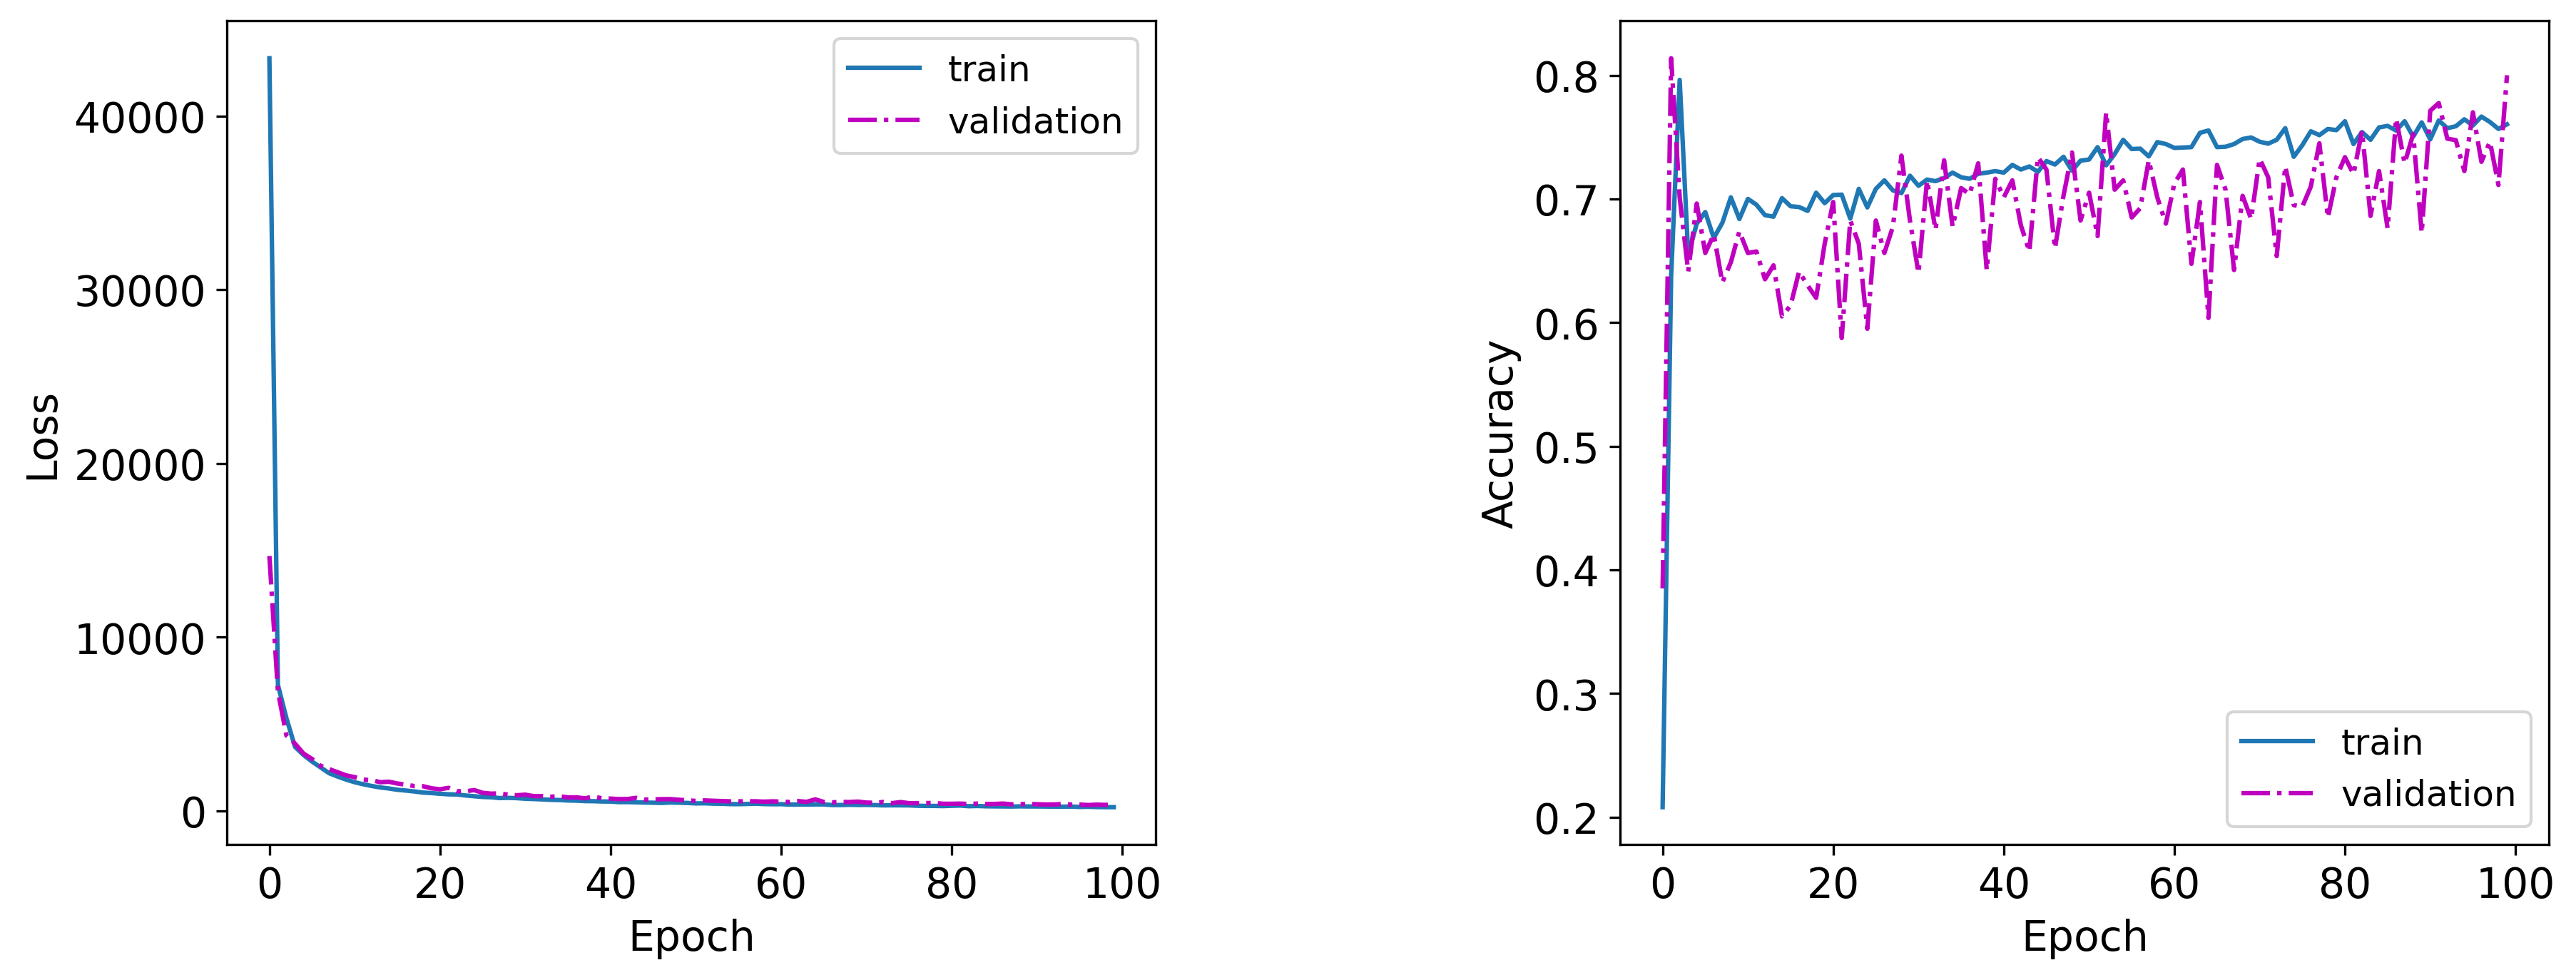

In [23]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet.history['loss'], label = 'train') #mynet.history guarda la historia en cada época de la red
plt.plot(mynet.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet.history['accuracy'], label = 'train')
plt.plot(mynet.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.show()

#plt.savefig('FirstNN.png', dpi= 300)

### (Paréntesis)
### Ahora pruebe usted

Usando el mismo código de arriba como plantilla, modifíquelo para responder:

No hace falta entrenar todavía, solo construyan el modelo con `model.summary()` al final y observe cómo cambia el número de parámetros totales según sus decisiones.

#### Agregando capa oculta

**¿Qué pasa si agrega una tercera capa oculta?** Agréguela (por ejemplo, de tamaño 20 también) y comenten: ¿por qué una arquitectura más profunda podría ayudar o no ayudar en este problema? 
- **En teoría una arquitectura más profunda permitiría establecer relaciones más complejas de las variables, pero para este caso es posible que se genere inestabilidad porque los datos no están normalizados**

In [24]:
model2 = Sequential() # modelo 2 con tercera capa oculta

# Primera capa oculta, especificamos el tamaño del input (número de características originales)

model2.add(Dense(20, activation='relu', input_shape=(24,))) # Dense: conectada con input y output
# input solo capa de entrada

# Agrega una  segunda capa oculta y especificamos el tamaño

model2.add(Dense(20, activation='relu'))

# agregamos una tercera capa oculta de tamaño 20

model2.add(Dense(20, activation='relu')) 

# Agrega capa de salida

model2.add(Dense(1, activation='sigmoid')) # 1 neurona

model2.summary() # resumen de la arquitectura


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,361 (5.32 KB)

 Trainable params: 1,361 (5.32 KB)

 Non-trainable params: 0 (0.00 B)

#### Cambiando capas ocultas

**¿Qué pasa si cambia el tamaño de las capas ocultas** (por ejemplo, de 20 a 5, o de 20 a 100)? Antes de correrlo: ¿espera que la red sea más lenta o más rápida de entrenar? ¿Más o menos propensa a sobreajustar?
- **Una red con menos capas ocultas debería ser más rápida de entrenar y menos propensa a sobreajustar por falta de complejidad. Si tenemos más capas ocultas, como 100 en este caso, ocurre lo contrario.**

In [25]:
model3 = Sequential() # modelo 3 con tercera capa oculta y cambiando su tamaño a 5 neuronas

# Primera capa oculta, especificamos el tamaño del input (número de características originales)

model3.add(Dense(5, activation='relu', input_shape=(24,))) # Dense: conectada con input y output
# input solo capa de entrada

# Agrega una  segunda capa oculta y especificamos el tamaño en 5

model3.add(Dense(5, activation='relu'))

# agregamos una tercera capa oculta de tamaño 5

model3.add(Dense(5, activation='relu')) 

# Agrega capa de salida

model3.add(Dense(1, activation='sigmoid')) # 1 neurona

model3.summary() # resumen de la arquitectura

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 5)              │           125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191 (764.00 B)

 Trainable params: 191 (764.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
model3_ = Sequential() # modelo 3 con tercera capa oculta y cambiando su tamaño a 100 neuronas

# Primera capa oculta, especificamos el tamaño del input (número de características originales)

model3_.add(Dense(100, activation='relu', input_shape=(24,))) # Dense: conectada con input y output
# input solo capa de entrada

# Agrega una  segunda capa oculta y especificamos el tamaño en 100

model3_.add(Dense(100, activation='relu'))

# agregamos una tercera capa oculta de tamaño 100

model3_.add(Dense(100, activation='relu')) 

# Agrega capa de salida

model3_.add(Dense(1, activation='sigmoid')) # 1 neurona

model3_.summary() # resumen de la arquitectura

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 100)            │         2,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,801 (89.07 KB)

 Trainable params: 22,801 (89.07 KB)

 Non-trainable params: 0 (0.00 B)

#### Usando otra función de activación

**¿Qué pasa si usa otra función de activación** en las capas ocultas (por ejemplo `tanh` en vez de `relu`)? Revise la lista de activaciones disponibles que exploramos arriba con `dir(keras.activations)`.

- **Probablemente un cambio en los gradientes.**

In [27]:
model4 = Sequential() # modelo 4 con tercera capa oculta, cambiando su tamaño y con otra función de activación

# Primera capa oculta, especificamos el tamaño del input (número de características originales)

# usamos activación tanh

model4.add(Dense(20, activation='tanh', input_shape=(24,))) # Dense: conectada con input y output
# input solo capa de entrada

# Agrega una  segunda capa oculta y especificamos el tamaño en 5

model4.add(Dense(5, activation='tanh'))

# agregamos una tercera capa oculta de tamaño 100

model4.add(Dense(100, activation='tanh')) 

# Agrega capa de salida

model4.add(Dense(1, activation='tanh')) # 1 neurona

model4.summary() # resumen de la arquitectura


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 5)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,306 (5.10 KB)

 Trainable params: 1,306 (5.10 KB)

 Non-trainable params: 0 (0.00 B)

### (Cierre paréntesis)

Al ver accuracy notamos que el resultado de la red es bastante inestable en comparación a la pérdida, alredeor de la época 100 tenemos un 0.65. Queremos que el accuracy sea más estable. 

### Diagnóstico

El accuracy salió mucho peor de lo esperado. Antes de seguir:

1. Corra `X.describe()` en la celda de abajo y miren los rangos (min, max, mean) de las distintas columnas.

In [28]:
X.describe()

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
count,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2499.500000,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704,6.245400,1.418200,4.49240,0.030400,0.304400
std,1443.520003,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070,2.157709,0.955767,2.03479,0.171702,0.519418
min,0.000000,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130,1.000000,0.000000,0.00000,0.000000,0.000000
25%,1249.750000,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080,5.000000,1.000000,3.00000,0.000000,0.000000
50%,2499.500000,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000,6.000000,1.000000,4.00000,0.000000,0.000000
75%,3749.250000,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765,7.000000,2.000000,6.00000,0.000000,1.000000
max,4999.000000,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660,13.000000,6.000000,13.00000,1.000000,3.000000


2. ¿Ve algo que podría estar afectando el entrenamiento por gradiente descendiente?

- **Lo cierto es que vemos una extrema diferencia entre los valores mínimos y máximos de algunas componentes, con algunas oscilando el valor 0 y otras ordenes de magnitud mayores (observemos P2 y P3 por ejemplo).**

3. Le parece que la curva de la pérdida es suficiente para el diagnóstico del modelo?

- **La curva de pérdida no es suficiente, en especial si hay escalas tan distintas en los datos. Podría haber un sesgo que favorezca los datos con pesos desorbitados. Es necesario usar métricas.**

### Nos olvidamos de escalar (por qué es necesario??)

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
scaler = StandardScaler()

Escalamos sólo los datos del set entrenamiento (para evitar leakage)

In [31]:
scaler.fit(X_train)

StandardScaler()

In [32]:
Xst_train = scaler.transform(X_train)
Xst_val = scaler.transform(X_val)
Xst_test = scaler.transform(X_test)

### Reentrenamos la red

In [33]:
model_st = Sequential()
model_st.add(Dense(20, activation='relu', input_shape=(24,)))
model_st.add(Dense(20, activation='relu'))
model_st.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_st.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_st = model_st.fit(
    Xst_train, y_train, validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, verbose=0) #verbose=0 para no mostrar el resultado en cada epoca

/home/mars/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


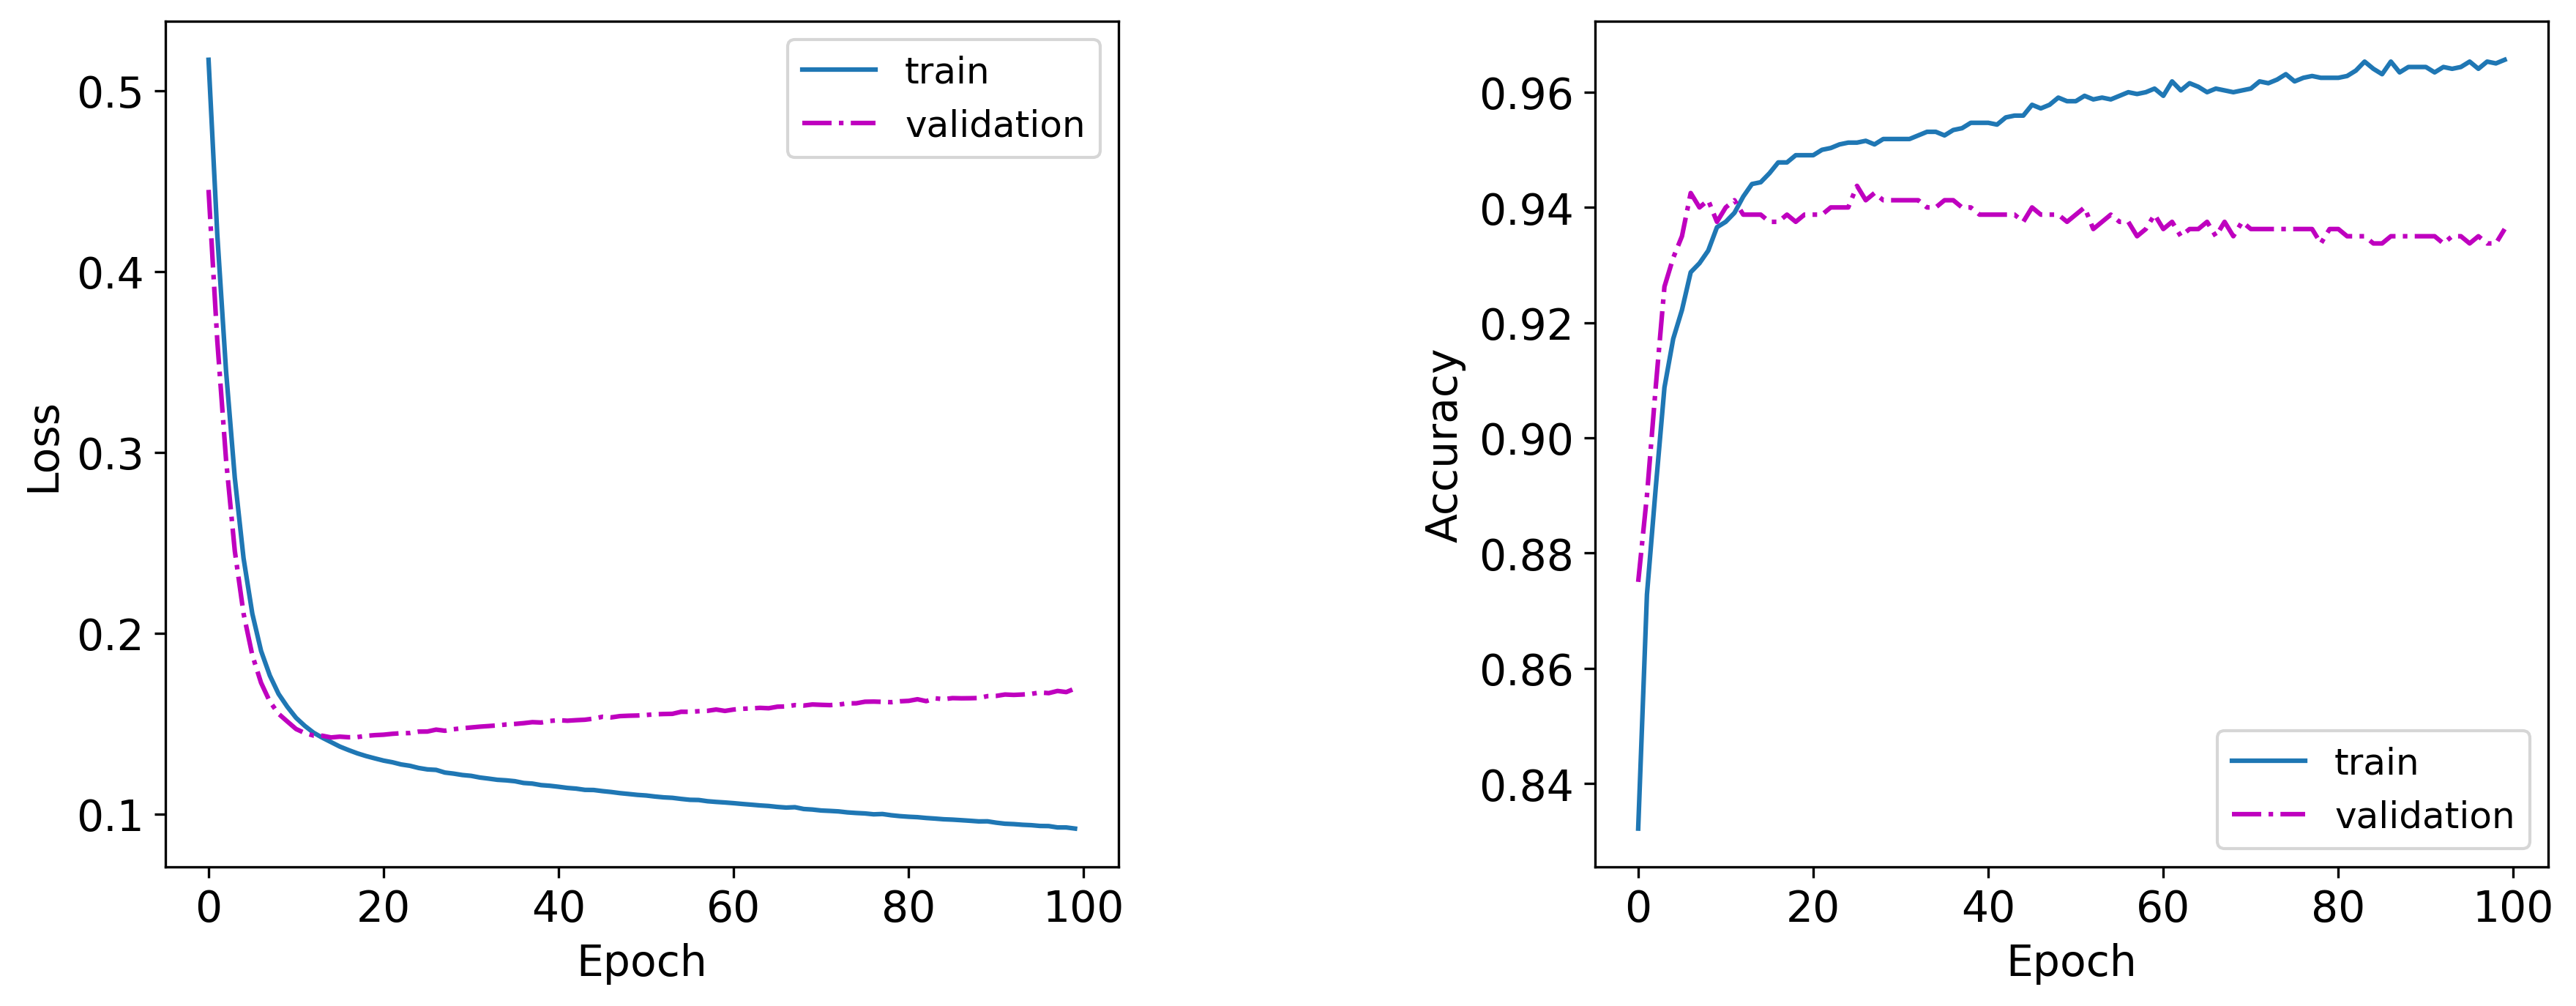

In [34]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_st.history['loss'], label = 'train')
plt.plot(mynet_st.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_st.history['accuracy'], label = 'train')
plt.plot(mynet_st.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)
#plt.show()

#plt.savefig('ScaledNN.png', dpi= 300)

#### Ahora se ve mucho mejor el comportamiento de la red, y además se alcanza un accuracy similar a lo que obtuvimos con SVMs

Esto es común para datos tabulares, que tienen relaciones más simples y en general no contienen demasiados datos. Las NN funcionan mejor para datos más complejos, como audio, imágenes, texto

### Diagnóstico

Mire las curvas de loss y accuracy  (train vs. validación, con datos escalados).

1. ¿Hay separación entre las curvas de train y validación? ¿Es una separación que se mantiene estable, o una que crece con las épocas?

- **Existe una separación entre ambas curvas que comienza alrededor de los 15-20 epoch. La separación se mantiene estable hasta incluso los 100 epoch.**

2. ¿Esto califica como overfitting severo, overfitting leve, o no hay overfitting? Justifique mirando específicamente sus números, no una regla general.

- **Califica como overfitting leve: el loss de entrenamiento baja y el accuracy sube.**

3. Según su diagnóstico, ¿tiene sentido aplicar regularización acá, o el modelo ya está bien como está?

-  **La regularización tendría sentido para evitar que el modelo deje de memorizar a partir del momento en que las curvas se separan.**

### Ahora pruebe usted

La red original cuenta con dos capas ocultas de 20 neuronas cada una, ReLU, y salida sigmoide, entrenada con datos escalados. Usando ese mismo código como plantilla, construya y entrene tres variantes, una a la vez:

### 3 capas ocultas Modelo 2

In [38]:
optimizer2 = tf.keras.optimizers.Adam(learning_rate=0.001)

model2.compile(loss='binary_crossentropy', optimizer=optimizer2, metrics = ['accuracy'])

In [39]:
%%time

# fit modelo 2
mynet2 = model2.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs = 100,  batch_size=200) 

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8378 - loss: 0.4917 - val_accuracy: 0.8375 - val_loss: 0.4505
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8413 - loss: 0.4078 - val_accuracy: 0.8425 - val_loss: 0.3755
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8534 - loss: 0.3373 - val_accuracy: 0.8737 - val_loss: 0.3120
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8897 - loss: 0.2857 - val_accuracy: 0.9062 - val_loss: 0.2671
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9131 - loss: 0.2471 - val_accuracy: 0.9175 - val_loss: 0.2306
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9237 - loss: 0.2148 - val_accuracy: 0.9250 - val_loss: 0.2033
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9284 - loss: 0.1908 - val_accuracy: 0.9325 - val_loss: 0.1823
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9325 - loss: 0.1745 - val_accuracy: 0.9325 

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9653 - loss: 0.0981 - val_accuracy: 0.9400 - val_loss: 0.1560
Epoch 52/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9644 - loss: 0.0971 - val_accuracy: 0.9400 - val_loss: 0.1574
Epoch 53/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9647 - loss: 0.0963 - val_accuracy: 0.9400 - val_loss: 0.1564
Epoch 54/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9644 - loss: 0.0952 - val_accuracy: 0.9400 - val_loss: 0.1594
Epoch 55/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9647 - loss: 0.0946 - val_accuracy: 0.9400 - val_loss: 0.1600
Epoch 56/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9653 - loss: 0.0944 - val_accuracy: 0.9400 - val_loss: 0.1599
Epoch 57/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9656 - loss: 0.0932 - val_accuracy: 0.9400 - val_loss: 0.1603
Epoch 58/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9659 - loss: 0.0923 - val_accuracy: 0.9388 - val_l

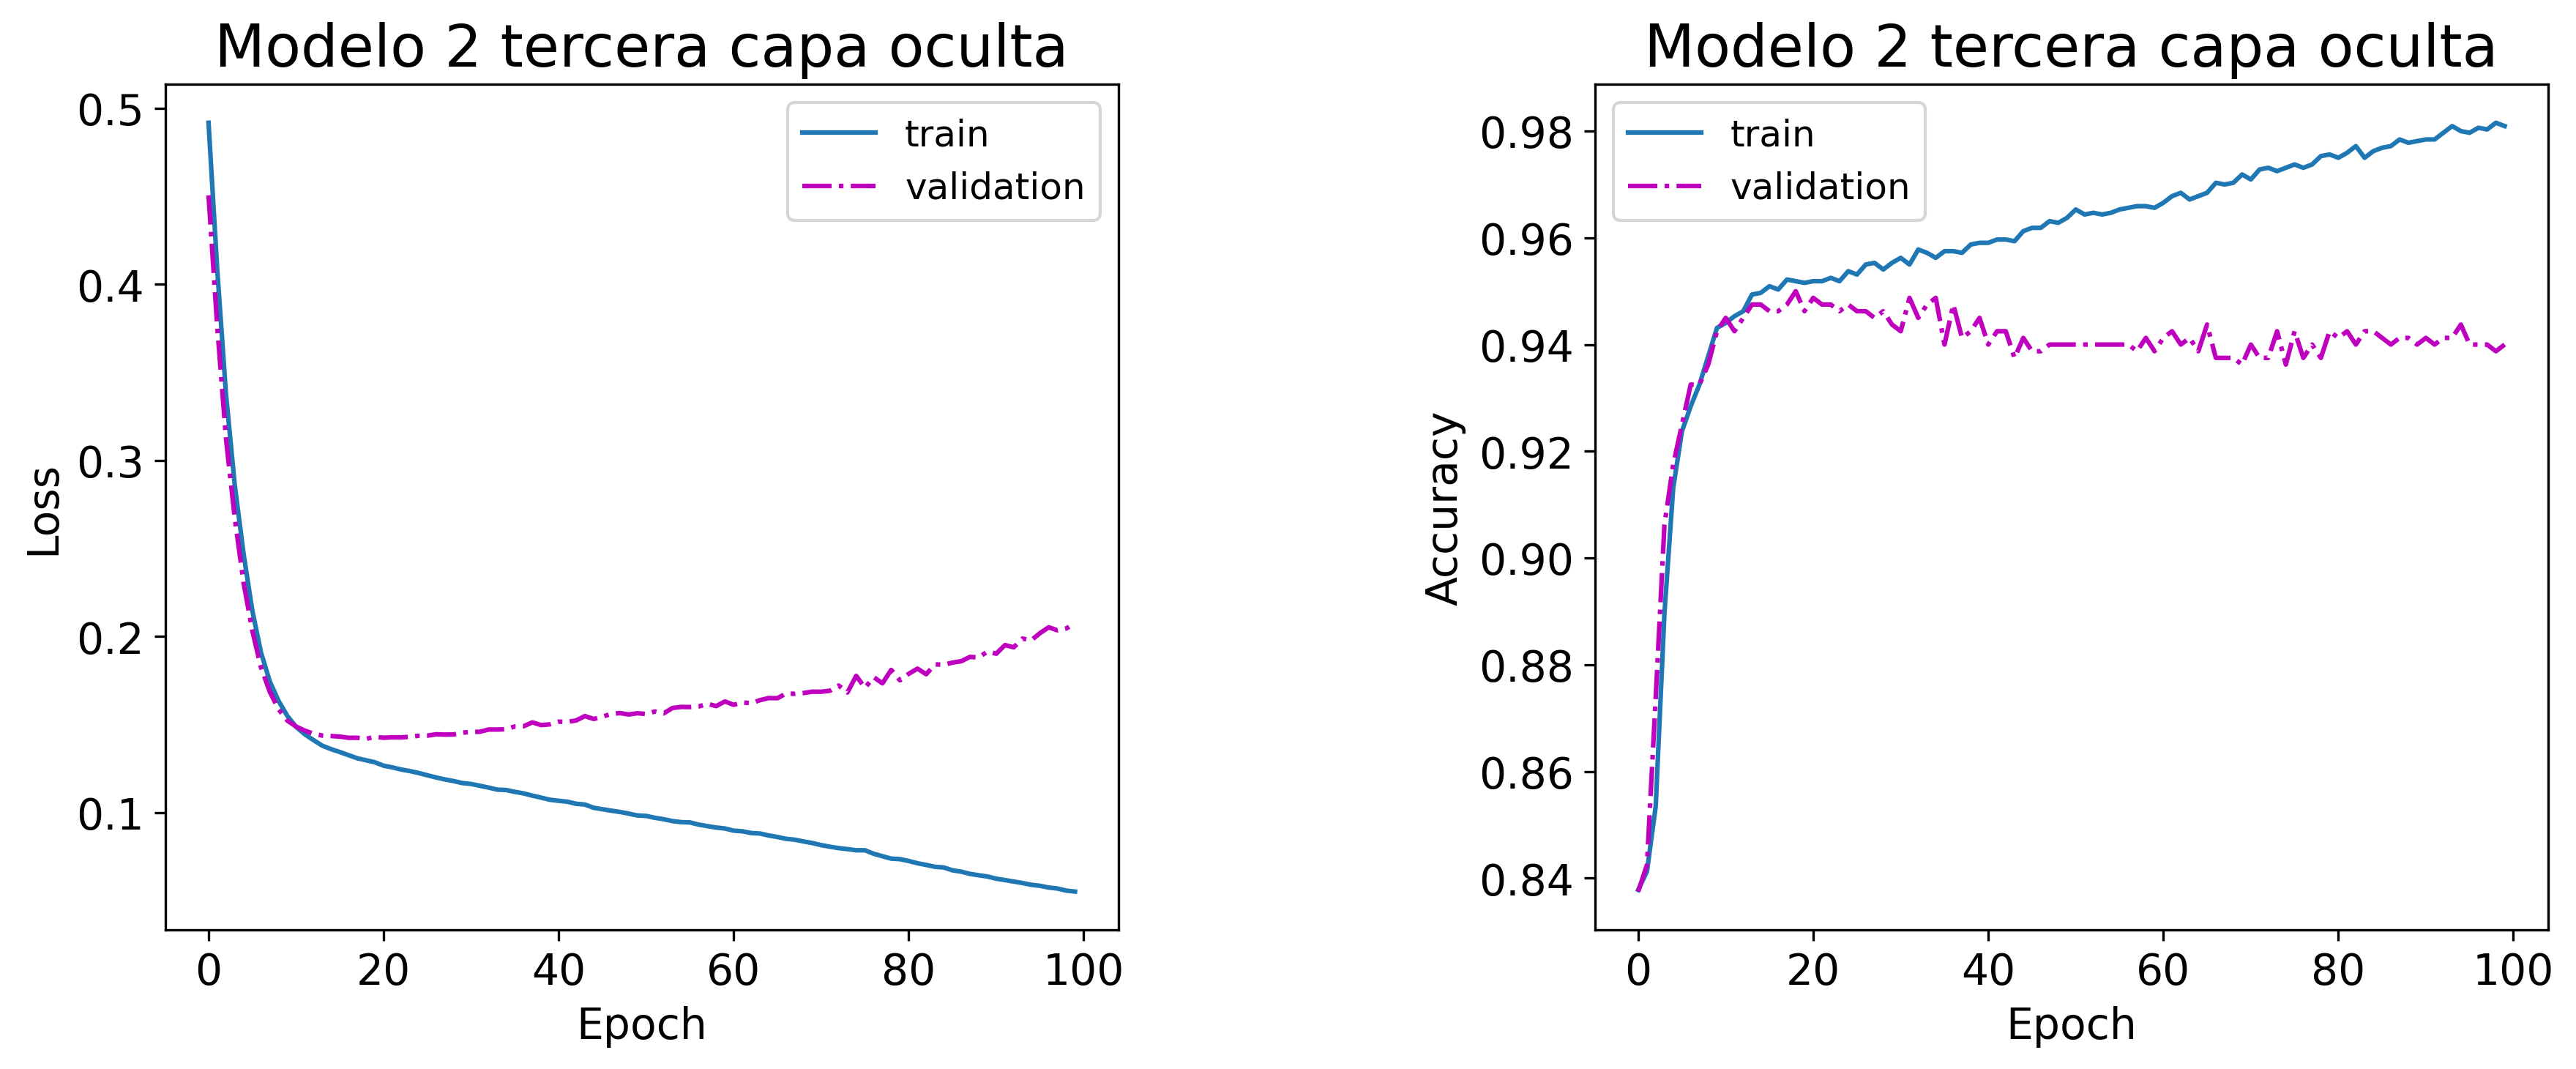

In [40]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet2.history['loss'], label = 'train') #mynet.history guarda la historia en cada época de la red
plt.plot(mynet2.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.title("Modelo 2 tercera capa oculta")
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet2.history['accuracy'], label = 'train')
plt.plot(mynet2.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.title("Modelo 2 tercera capa oculta")
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.show()

#plt.savefig('FirstNN.png', dpi= 300)

1. **Agregue una tercera capa oculta** (de 20 neuronas también). ¿Mejora, empeora, o no cambia mucho el accuracy de validación? ¿Por qué creen que pasa eso en este dataset específico?

- **La verdad el accuracy de validación no cambia mucho. El modelo parece memorizar a partir del epoch 20, puede ser porque el dataset no es suficientemente extenso.**

### Capas de 5 neuronas Modelo 3

In [41]:
optimizer3 = tf.keras.optimizers.Adam(learning_rate=0.001)

model3.compile(loss='binary_crossentropy', optimizer=optimizer3, metrics = ['accuracy'])

In [42]:
%%time

# fit modelo 3
mynet3 = model3.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs = 100,  batch_size=200)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3672 - loss: 0.7524 - val_accuracy: 0.4437 - val_loss: 0.7016
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4819 - loss: 0.6863 - val_accuracy: 0.5700 - val_loss: 0.6390
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6156 - loss: 0.6274 - val_accuracy: 0.6862 - val_loss: 0.5805
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7181 - loss: 0.5725 - val_accuracy: 0.7725 - val_loss: 0.5281
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7853 - loss: 0.5237 - val_accuracy: 0.8313 - val_loss: 0.4825
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8259 - loss: 0.4820 - val_accuracy: 0.8438 - val_loss: 0.4410
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8447 - loss: 0.4443 - val_accuracy: 0.8625 - val_loss: 0.4035
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8534 - loss: 0.4097 - val_accuracy: 0.8600 -

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9488 - loss: 0.1385 - val_accuracy: 0.9413 - val_loss: 0.1498
Epoch 52/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9491 - loss: 0.1379 - val_accuracy: 0.9438 - val_loss: 0.1487
Epoch 53/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9491 - loss: 0.1372 - val_accuracy: 0.9413 - val_loss: 0.1496
Epoch 54/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9494 - loss: 0.1367 - val_accuracy: 0.9413 - val_loss: 0.1493
Epoch 55/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9491 - loss: 0.1361 - val_accuracy: 0.9413 - val_loss: 0.1492
Epoch 56/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9506 - loss: 0.1357 - val_accuracy: 0.9400 - val_loss: 0.1500
Epoch 57/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9503 - loss: 0.1350 - val_accuracy: 0.9413 - val_loss: 0.1494
Epoch 58/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9500 - loss: 0.1346 - val_accuracy: 0.9438 - val_lo

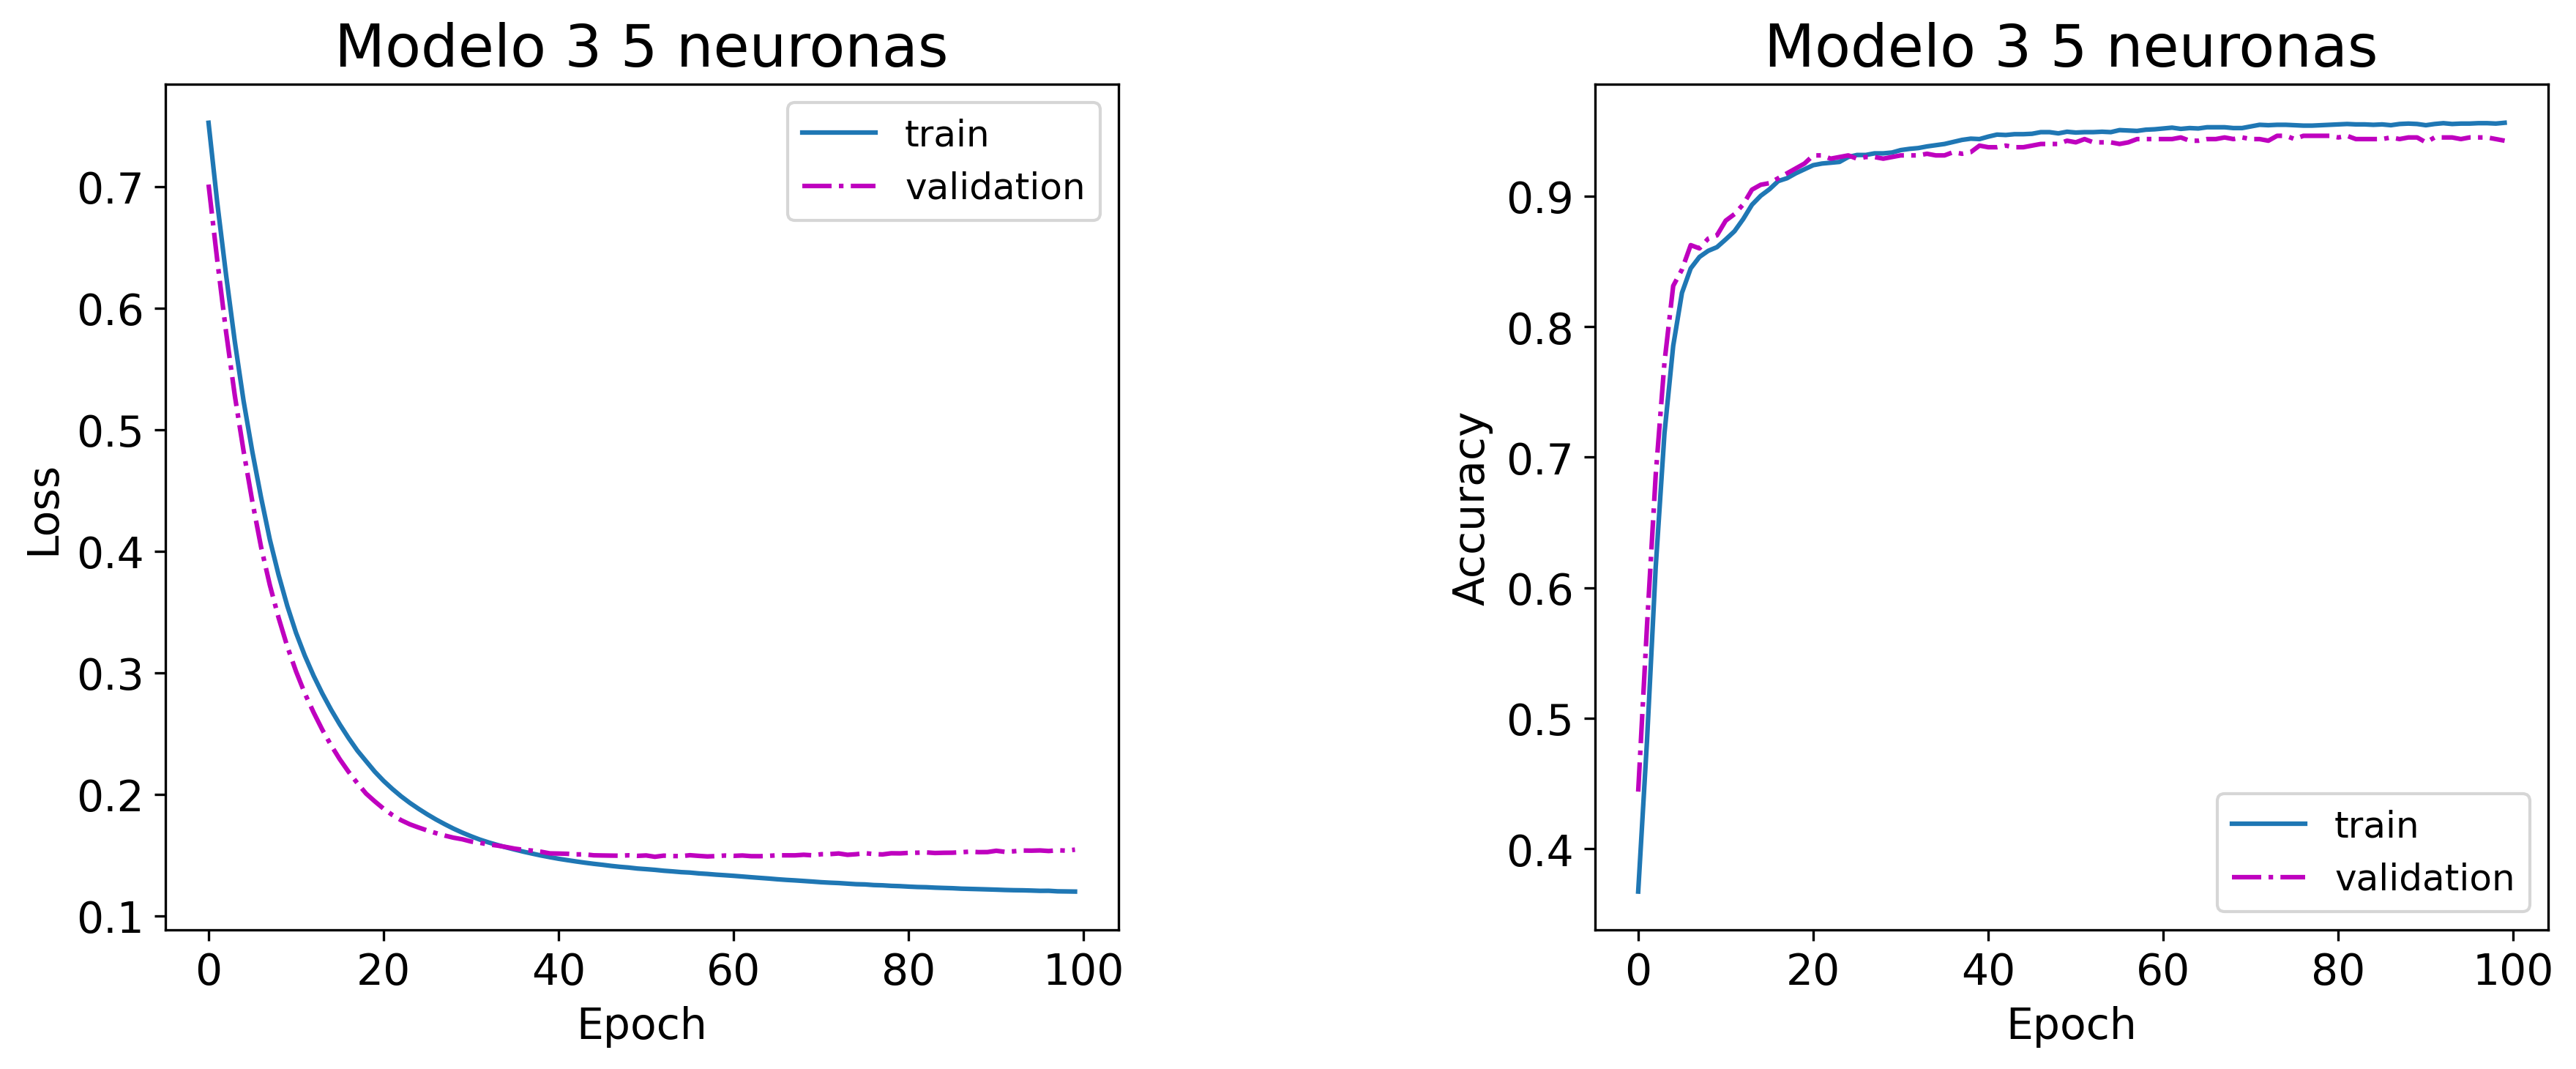

In [43]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet3.history['loss'], label = 'train') #mynet.history guarda la historia en cada época de la red
plt.plot(mynet3.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.title("Modelo 3 5 neuronas")
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet3.history['accuracy'], label = 'train')
plt.plot(mynet3.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.title("Modelo 3 5 neuronas")
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.show()

#plt.savefig('FirstNN.png', dpi= 300)

### Capas de 100 neuronas Modelo 3

In [44]:
optimizer3_ = tf.keras.optimizers.Adam(learning_rate=0.001)

model3_.compile(loss='binary_crossentropy', optimizer=optimizer3_, metrics = ['accuracy'])

In [45]:
%%time

# fit modelo 3
mynet3_ = model3_.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs = 100,  batch_size=200)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7816 - loss: 0.4955 - val_accuracy: 0.8725 - val_loss: 0.2889
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9125 - loss: 0.2179 - val_accuracy: 0.9375 - val_loss: 0.1609
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9353 - loss: 0.1553 - val_accuracy: 0.9362 - val_loss: 0.1431
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9469 - loss: 0.1382 - val_accuracy: 0.9400 - val_loss: 0.1451
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9478 - loss: 0.1314 - val_accuracy: 0.9425 - val_loss: 0.1437
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9519 - loss: 0.1246 - val_accuracy: 0.9438 - val_loss: 0.1434
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9528 - loss: 0.1203 - val_accuracy: 0.9388 - val_loss: 0.1459
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9572 - loss: 0.1145 - val_accuracy: 0.9362

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9262 - val_loss: 0.4682
Epoch 52/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9250 - val_loss: 0.4767
Epoch 53/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9262 - val_loss: 0.4835
Epoch 54/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9262 - val_loss: 0.4905
Epoch 55/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 9.1792e-04 - val_accuracy: 0.9225 - val_loss: 0.4943
Epoch 56/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 8.7134e-04 - val_accuracy: 0.9250 - val_loss: 0.4967
Epoch 57/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 7.9558e-04 - val_accuracy: 0.9250 - val_loss: 0.5022
Epoch 58/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 7.5861e-04 - val_accuracy

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 1.3041e-04 - val_accuracy: 0.9237 - val_loss: 0.6380
CPU times: user 25.2 s, sys: 1.65 s, total: 26.8 s
Wall time: 19.4 s


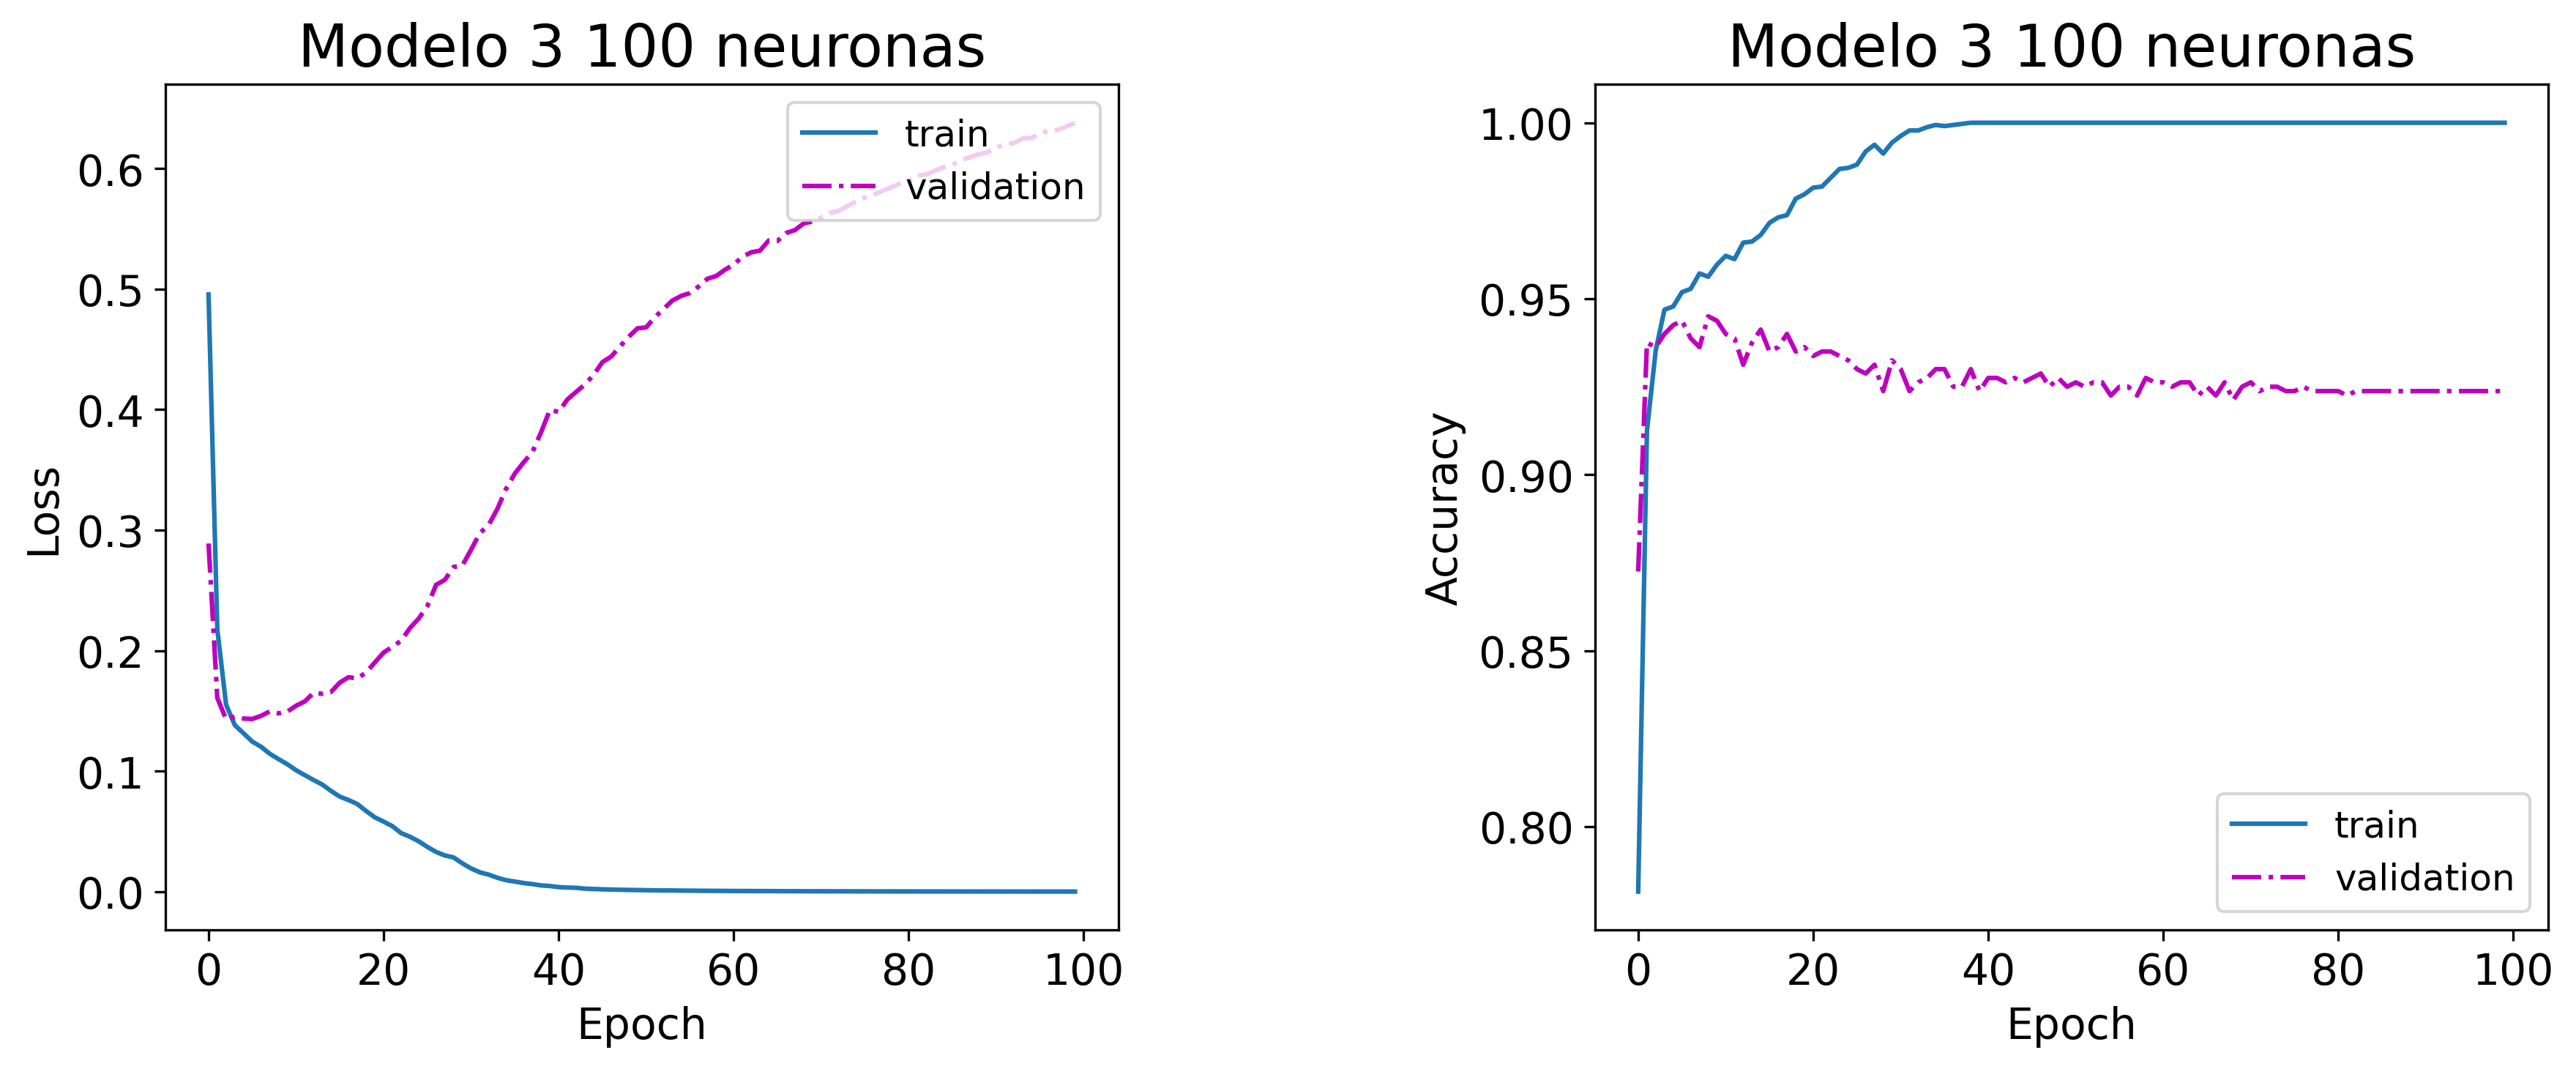

In [46]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet3_.history['loss'], label = 'train') #mynet.history guarda la historia en cada época de la red
plt.plot(mynet3_.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.title("Modelo 3 100 neuronas")
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet3_.history['accuracy'], label = 'train')
plt.plot(mynet3_.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.title("Modelo 3 100 neuronas")
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.show()

#plt.savefig('FirstNN.png', dpi= 300)

2. **Cambie el tamaño de las capas ocultas** a algo mucho más chico (5 neuronas) y después a algo mucho más grande (100 neuronas). ¿Cuál entrena más lento? ¿Cuál muestra más señales de sobreajuste en las curvas de loss?

- **Entrena más lento el de 100 neuronas, aunque no por mucho. Definitivamente el de 100 neuronas muestra un sobreajuste brutal; las curvas están evidentemente muy separadas.***

### Activación tanh 

In [47]:
optimizer4 = tf.keras.optimizers.Adam(learning_rate=0.001)

model4.compile(loss='binary_crossentropy', optimizer=optimizer4, metrics = ['accuracy'])

In [48]:
%%time

# fit modelo 4
mynet4 = model4.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs = 100,  batch_size=200)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8163 - loss: 1.3950 - val_accuracy: 0.8300 - val_loss: 0.9888
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8328 - loss: 0.6305 - val_accuracy: 0.8338 - val_loss: 0.4744
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8425 - loss: 0.4007 - val_accuracy: 0.8500 - val_loss: 0.3719
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8578 - loss: 0.3494 - val_accuracy: 0.8650 - val_loss: 0.3182
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8703 - loss: 0.3063 - val_accuracy: 0.8675 - val_loss: 0.2956
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8841 - loss: 0.2838 - val_accuracy: 0.8850 - val_loss: 0.2797
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8981 - loss: 0.2683 - val_accuracy: 0.9025 - val_loss: 0.2751
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9062 - loss: 0.2533 - val_accuracy: 0.9062 - 

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9269 - loss: 0.1826 - val_accuracy: 0.9212 - val_loss: 0.2231
Epoch 52/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9303 - loss: 0.1800 - val_accuracy: 0.9237 - val_loss: 0.2209
Epoch 53/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9316 - loss: 0.1782 - val_accuracy: 0.9225 - val_loss: 0.2190
Epoch 54/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9312 - loss: 0.1766 - val_accuracy: 0.9262 - val_loss: 0.2180
Epoch 55/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9316 - loss: 0.1752 - val_accuracy: 0.9262 - val_loss: 0.2165
Epoch 56/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9334 - loss: 0.1739 - val_accuracy: 0.9262 - val_loss: 0.2158
Epoch 57/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9356 - loss: 0.1728 - val_accuracy: 0.9275 - val_loss: 0.2147
Epoch 58/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9356 - loss: 0.1718 - val_accuracy: 0.9287 - val_lo

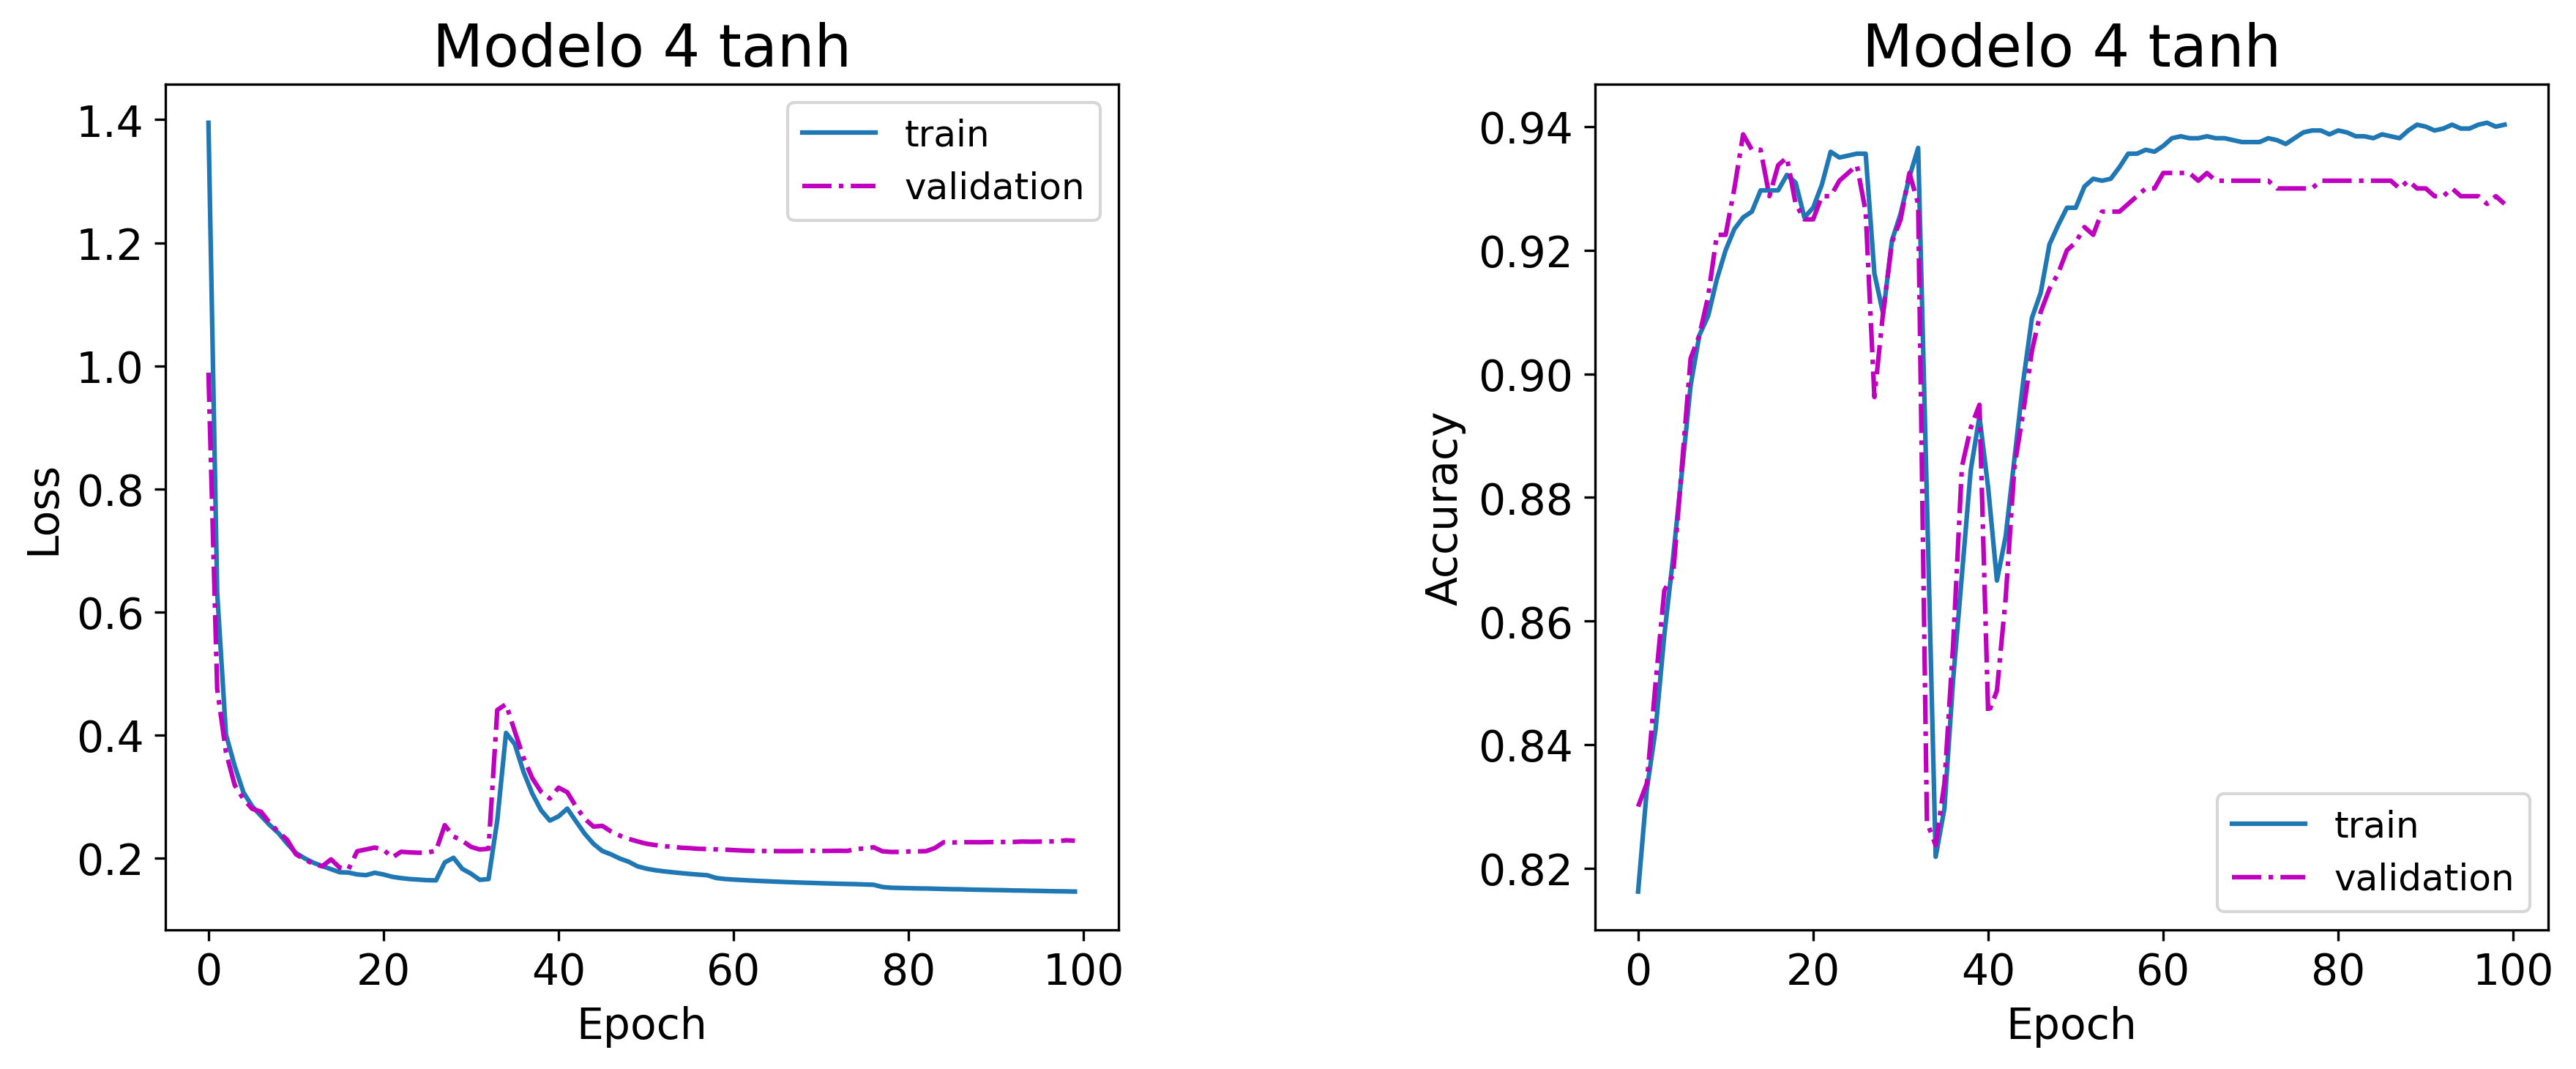

In [49]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet4.history['loss'], label = 'train') #mynet.history guarda la historia en cada época de la red
plt.plot(mynet4.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.title("Modelo 4 tanh")
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet4.history['accuracy'], label = 'train')
plt.plot(mynet4.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.title("Modelo 4 tanh")
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.show()

#plt.savefig('FirstNN.png', dpi= 300)

3. **Cambie la activación** de las capas ocultas de `relu` a `tanh`. Usen `dir(keras.activations)` si quieren ver más opciones. ¿Cambia la velocidad de convergencia?

- **Lo cierto es que la convergencia sucede a ritmo similar pero de forma errática, oscilando en el gráfico de accuracy.**

In [50]:
comparacion_modelos = pd.DataFrame([
    {"modelo": "escalado (sin regularizar)",
     "val_acc": mynet_st.history['val_accuracy'][-1],
     "val_loss": mynet_st.history['val_loss'][-1]},
    {"modelo": "escalado 3 capas",
     "val_acc": mynet2.history['val_accuracy'][-1],
     "val_loss": mynet2.history['val_loss'][-1]},
    {"modelo": "escalado 5 neuronas",
     "val_acc": mynet3.history['val_accuracy'][-1],
     "val_loss": mynet3.history['val_loss'][-1]},
    {"modelo": "escalado 100 neuronas",
     "val_acc": mynet3_.history['val_accuracy'][-1],
     "val_loss": mynet3_.history['val_loss'][-1]},
    {"modelo": "escalado tanh",
     "val_acc": mynet4.history['val_accuracy'][-1],
     "val_loss": mynet4.history['val_loss'][-1]},
])
comparacion_modelos

,modelo,val_acc,val_loss
0,escalado (sin regularizar),0.93625,0.169339
1,escalado 3 capas,0.94000,0.207585
2,escalado 5 neuronas,0.94250,0.154544
3,escalado 100 neuronas,0.92375,0.637984
4,escalado tanh,0.92750,0.227798


Rellene la tabla de comparación

| Variante | val_accuracy | val_loss | Comentario |
|---|---|---|---|
| Baseline (2 capas x 20, relu) |0.93625 |0.169339 |Razonable |
| 3 capas ocultas |0.94000 |0.207585 |Mejora leve |
| Capas de 5 neuronas |0.94250 |0.154544 |Más óptimo |
| Capas de 100 neuronas |0.92375 |0.637984 |Demasiada pérdida |
| Activación tanh |0.92750 |0.227798 |Empeoramiento leve |

### Regularización (por qué es necesaria??)

Dos estrategias razonables acá: parar el entrenamiento antes (**early stopping**, ~época 20-30,
donde val deja de mejorar), o agregar regularización con **dropout** y ver si empuja la curva de validación
más alto. Probemos ambas y comparemos.

### Antes de correr

Va a probar dos estrategias para esta brecha train/val: dropout y early stopping. Antes de correr ninguna:

- ¿Cuál de las dos cree que va a dar mejor accuracy en validación?

- **Dropout, al apagar neuronas al azar favorece la generalización.**

- ¿Cuál cree que va a ser más rápida de entrenar (menos épocas efectivas)?

- **Early stopping, ya que corta el entrenamiento.**

### Dropout

In [51]:
model_dropout = Sequential()

# Primera capa oculta, con el tamaño de la capa input especificado

model_dropout.add(Dense(20, activation='relu', input_shape=(24,)))

model_dropout.add(Dropout(0.2)) #fraccion de dropout

# Agregamos otra capa oculta y especificamos el tamaño

model_dropout.add(Dense(20, activation='relu'))

model_dropout.add(Dropout(0.2)) #fracción de dropout

#Agregamos capa de salida

model_dropout.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_dropout.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])

/home/mars/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
mynet_dropout = model_dropout.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs=100, batch_size=200, verbose=0)

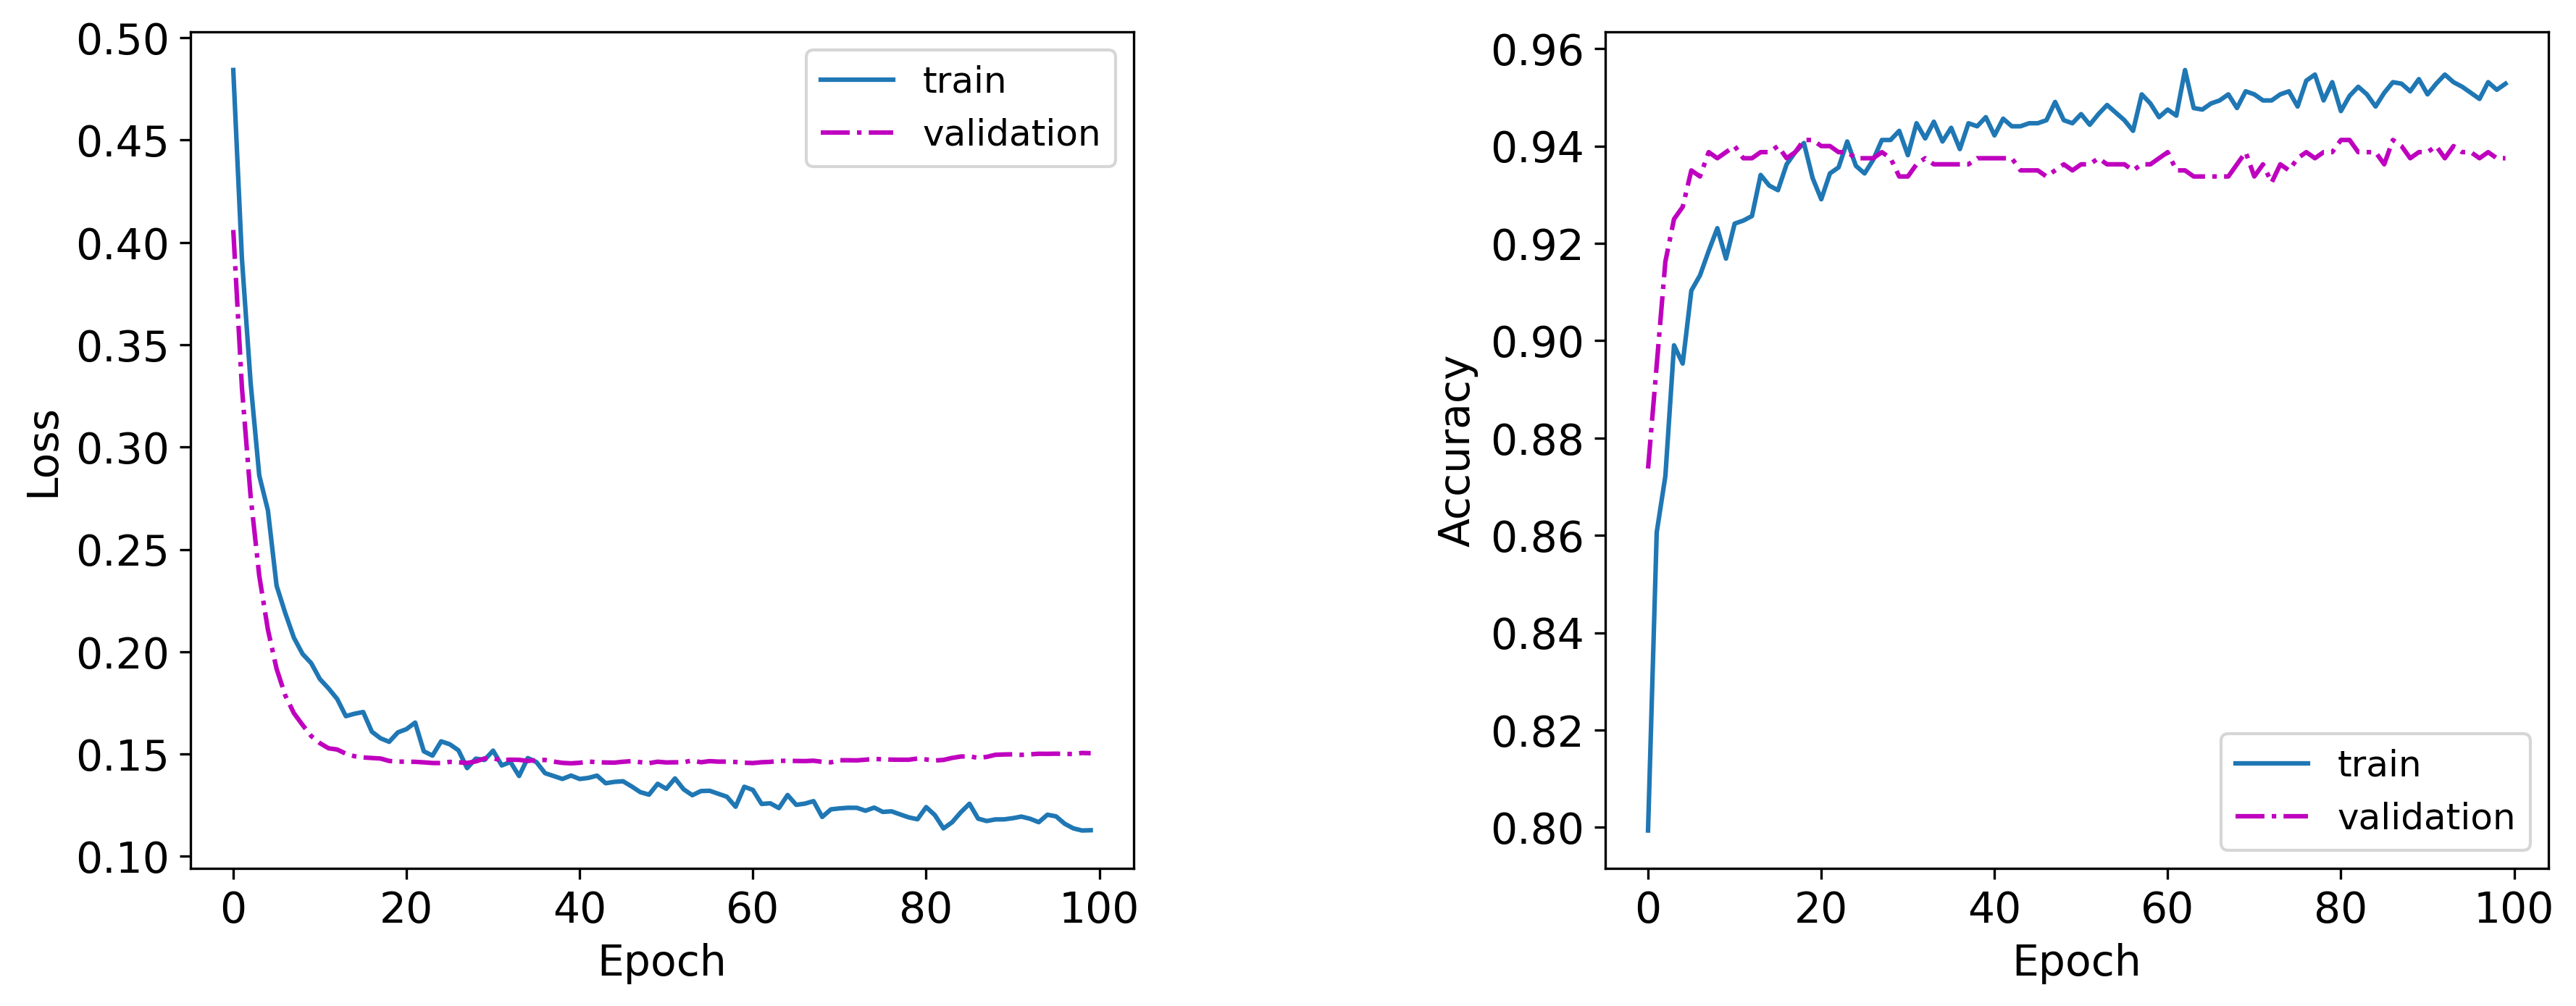

In [53]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_dropout.history['loss'], label = 'train')
plt.plot(mynet_dropout.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_dropout.history['accuracy'], label = 'train')
plt.plot(mynet_dropout.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('RegularizedNN.png', dpi= 300)
#plt.show()

### Early Stopping

In [54]:
%%time
from tensorflow.keras.callbacks import EarlyStopping

model_early = Sequential()
model_early.add(Dense(20, activation='relu', input_shape=(24,)))
model_early.add(Dense(20, activation='relu'))
model_early.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_early.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

mynet_early = model_early.fit(
    Xst_train, y_train, validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, callbacks=[early_stop], verbose=0)

print(f"Se detuvo en la época: {len(mynet_early.history['loss'])}")

Se detuvo en la época: 39
CPU times: user 8.49 s, sys: 507 ms, total: 9 s
Wall time: 8.28 s


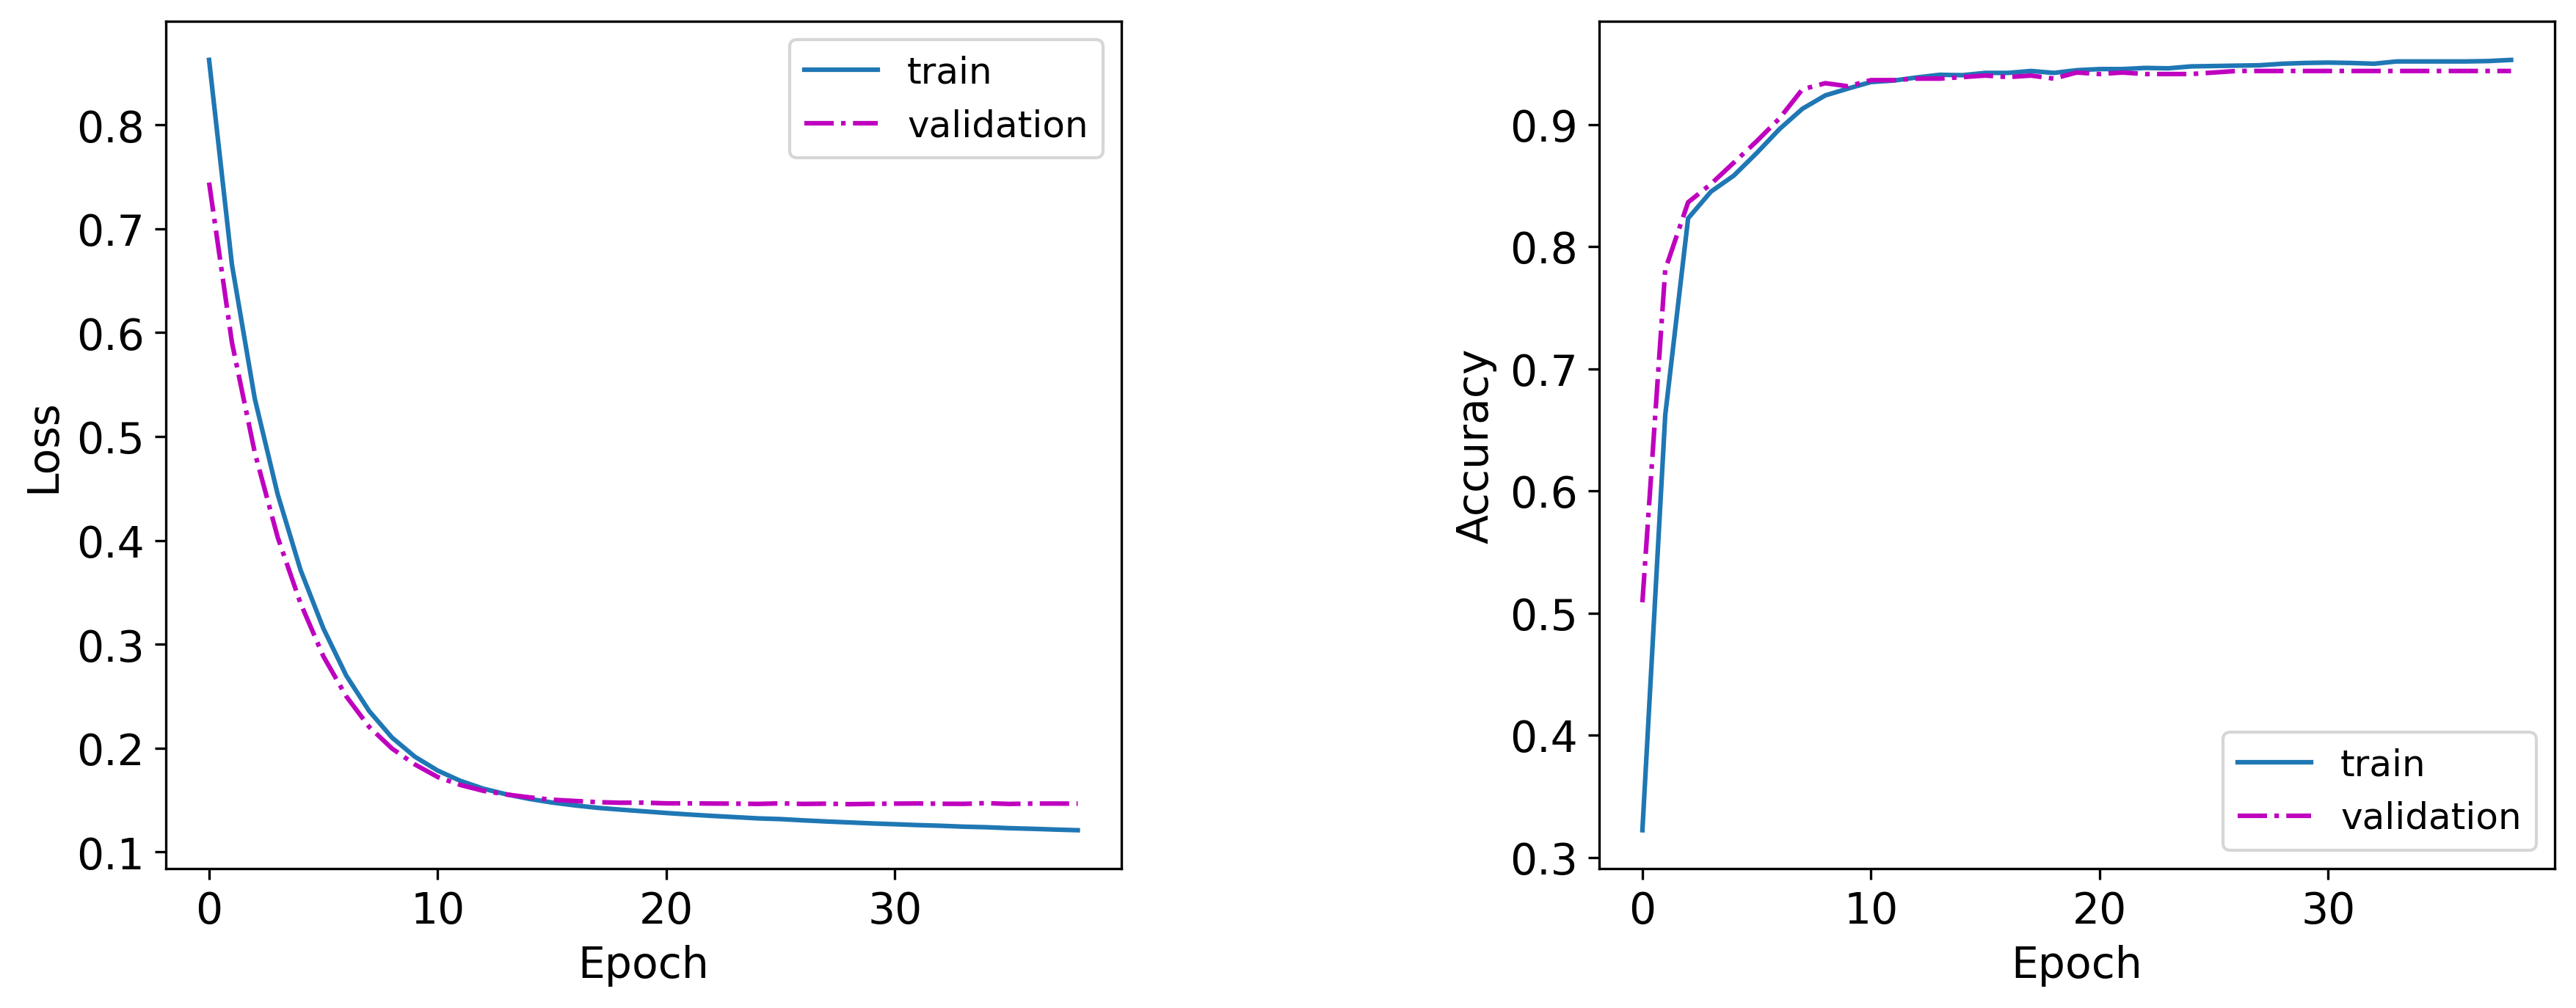

In [55]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_early.history['loss'], label = 'train')
plt.plot(mynet_early.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_early.history['accuracy'], label = 'train')
plt.plot(mynet_early.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('Regularized_Early_NN.png', dpi= 300)
#plt.show()

In [56]:
comparacion = pd.DataFrame([
    {"modelo": "escalado (sin regularizar)",
     "val_acc": mynet_st.history['val_accuracy'][-1],
     "val_loss": mynet_st.history['val_loss'][-1]},
    {"modelo": "escalado + dropout",
     "val_acc": mynet_dropout.history['val_accuracy'][-1],
     "val_loss": mynet_dropout.history['val_loss'][-1]},
    {"modelo": "escalado + early stopping",
     "val_acc": mynet_early.history['val_accuracy'][-1],
     "val_loss": mynet_early.history['val_loss'][-1]},
])
comparacion

,modelo,val_acc,val_loss
0,escalado (sin regularizar),0.93625,0.169339
1,escalado + dropout,0.93750,0.150355
2,escalado + early stopping,0.94375,0.146583


In [57]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

modelos = {
    "sin regularizar": model_st,
    "dropout": model_dropout,
    "early stopping": model_early,
}

for nombre, modelo in modelos.items():
    y_pred_proba = modelo.predict(Xst_test, verbose=0).ravel()
    y_pred = (y_pred_proba > 0.5).astype(int)

    print(f"=== {nombre} ===")
    print(classification_report(y_test, y_pred, target_names=["ttbar", "4top"]))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print()

=== sin regularizar ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.83      0.83      0.83       162

    accuracy                           0.94      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.95      0.94      0.95      1000

AUC-ROC: 0.9735
Matriz de confusión:
[[810  28]
 [ 27 135]]

=== dropout ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.84      0.85      0.84       162

    accuracy                           0.95      1000
   macro avg       0.90      0.91      0.91      1000
weighted avg       0.95      0.95      0.95      1000

AUC-ROC: 0.9785
Matriz de confusión:
[[811  27]
 [ 24 138]]

=== early stopping ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.84      0.84      0.84       16

In [58]:
comparacion = pd.DataFrame([
    {
        "modelo": nombre,
        "val_acc": modelo.evaluate(Xst_val, y_val, verbose=0)[1],
        "test_auc": roc_auc_score(y_test, modelo.predict(Xst_test, verbose=0).ravel()),
        "epocas": len(modelo.history.history['loss']) if hasattr(modelo, 'history') else None,
    }
    for nombre, modelo in modelos.items()
])
comparacion

,modelo,val_acc,test_auc,epocas
0,sin regularizar,0.93625,0.973533,100
1,dropout,0.93750,0.978491,100
2,early stopping,0.94375,0.976782,39


### Después de correr ambas: reflexión

Mire los números reales de dropout y early stopping.

1. Esperaba ese resultado? Explique

- **Esperaba que dropout tuviera mejores resultados, pero fue early stopping al tener un balance general un poco mejor en comparación, siguiendo las métricas.**

2. Dropout actúa *durante* el entrenamiento (apagando neuronas en cada paso). Early stopping actúa *deteniendo* el entrenamiento en un punto. ¿Por qué una de las dos estrategias podría funcionar mejor que la otra en este dataset específico, dado su tamaño y la arquitectura que están usando?

- **El dataset en este contexto se considera pequeño; early stopping corta el entrenamiento justo antes de que las curvas se comiencen a separar, en cambio, dropout es propenso a introducir ruido: debido a esto, en datasets pequeños funciona mejor early stopping.**

3. ¿Tendría sentido combinar ambas (dropout + early stopping) en vez de elegir una sola? ¿Por qué sí o por qué no?

- **Que se busque un equilibrio suele ser una buena práctica en la ciencia de datos. Combinar ambas podría implementar lo mejor de cada una: dropout favorece al aprendizaje y early stopping se asegura de no entrenar de más.**

4. Pruebe distintos valores de dropout y early stopping y discuta cómo cambian los resultados.

- **Con valores bajos de dropout no deberían haber grandes cambios, y con valores grandes el accuracy podría bajar. En cuanto al early stopping, con un valor bajo se podría detener el modelo antes de que suceda nada, mientras que con valores altos el efecto de este método podría perder sentido.**


### Optimización de hiperparámetros

Usaremos [`keras_tuner`](https://keras.io/keras_tuner/) para optimizar los hiperparámetros de la arquitectura de la red

### Antes de correr la búsqueda

Con lo que ya sabe del dataset y de los experimentos anteriores, responda:

- ¿Cuántas capas ocultas cree que va a preferir el mejor modelo?

- **Probablemente 2; como vimos antes, el modelo prefiere simpleza ya que no es un dataset muy grande en el contexto de NN.**

- ¿Dropout va a terminar en 0.0 o en un valor alto?

- **Debería ser un valor distinto de 0.0, pero no necesariamente alto.**

- ¿El learning rate óptimo va a ser más cercano a 0.0001 o a 0.01?

- **Probablemente más cercano al 0, si no, puede ser muy agresivo el gradiente.**

In [59]:
#!pip install keras-tuner  

In [60]:
import keras_tuner as kt

def build_model_tuner(hp):
    model = Sequential()

    #prueba con ndistintos numeros de neuronas, desde 8 a 64, cada 8,
    n_neurons = hp.Int("n_neurons", min_value=8, max_value=64, step=8)
    # activation = hp.Choice("activation", values=["relu", "tanh"])

    #construye la capa con la cantidad de neuronas que fijo en el paso anterior (cada capa con el mismo numero de neuronas)
    model.add(Dense(n_neurons, activation='relu', input_shape=(24,)))

    #numero de capas ocultas (1, 2, o 3)
    n_hidden = hp.Int("n_hidden", min_value=1, max_value=3)
    for i in range(n_hidden - 1):
        model.add(Dense(n_neurons, activation='relu'))

    #tasa de dropout (0.1-0.5, en pasos de 0.1)
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    #la capa de salida queda fija, para la clasificacion binaria
    model.add(Dense(1, activation='sigmoid'))

    #tasa de aprendizaje, entre 0.0001 y 0.01
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

#prueba solo combinaciones aleatorias para reducir costo computacional
tuner = kt.RandomSearch(
    build_model_tuner,
    objective="val_accuracy",
    max_trials=15,          # número de combinaciones a probar
    executions_per_trial=1,
    directory="tuner_resultados",
    project_name="particle_id",
)

tuner.search(
    Xst_train, y_train,
    validation_data=(Xst_val, y_val),
    epochs=30,
    batch_size=200,
    verbose=1,
)

Reloading Tuner from tuner_resultados/particle_id/tuner0.json


In [61]:
%%time 
# Mejor modelo encontrado
mejores_hp = tuner.get_best_hyperparameters(1)[0]
print("Mejores hiperparámetros:")
for param in mejores_hp.values:
    print(f"  {param}: {mejores_hp.values[param]}")

Mejores hiperparámetros:
  n_neurons: 48
  n_hidden: 3
  dropout_rate: 0.30000000000000004
  learning_rate: 0.0014915634081643745
CPU times: user 333 µs, sys: 0 ns, total: 333 µs
Wall time: 309 µs


### Evaluamos finalmente el modelo con el set de prueba, que sólo se usa en el paso final

In [62]:
mejor_modelo = tuner.get_best_models(1)[0]
scores = mejor_modelo.evaluate(Xst_test, y_test, verbose=0)
print(f"\nAccuracy en test: {scores[1]:.4f}")

/home/mars/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/mars/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Accuracy en test: 0.9480


In [63]:
# Resumen de los mejores trials
tuner.results_summary(num_trials=5)

Results summary
Results in tuner_resultados/particle_id
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 04 summary
Hyperparameters:
n_neurons: 48
n_hidden: 3
dropout_rate: 0.30000000000000004
learning_rate: 0.0014915634081643745
Score: 0.9449999928474426

Trial 10 summary
Hyperparameters:
n_neurons: 40
n_hidden: 2
dropout_rate: 0.2
learning_rate: 0.0002801981642932787
Score: 0.9449999928474426

Trial 08 summary
Hyperparameters:
n_neurons: 48
n_hidden: 1
dropout_rate: 0.2
learning_rate: 0.001221940430262526
Score: 0.9437500238418579

Trial 02 summary
Hyperparameters:
n_neurons: 56
n_hidden: 1
dropout_rate: 0.0
learning_rate: 0.00036738608730941267
Score: 0.9424999952316284

Trial 03 summary
Hyperparameters:
n_neurons: 40
n_hidden: 3
dropout_rate: 0.4
learning_rate: 0.00011519880606550622
Score: 0.9424999952316284


### Mire los 5 mejores trials, no solo el ganador


1. ¿Hay algún empate o casi-empate en el score entre dos trials? Compare sus arquitecturas (n_neurons, n_hidden) y su dropout_rate uno al lado del otro, ¿qué tan distintos son entre sí?

Empate 1 Score: 0.945:

Trial 04: n_neurons: 48 | n_hidden: 3 | dropout_rate: 0.3

Trial 10: n_neurons: 40 | n_hidden: 2 | dropout_rate: 0.2

Empate 2 Score: 0.942:

Trial 02: n_neurons: 56 | n_hidden: 1 | dropout_rate: 0.0

Trial 03: n_neurons: 40 | n_hidden: 3 | dropout_rate: 0.4

**Las diferencias son grandes. En el primer empate, tenemos diferencias en las capas ocultas. En el segundo, el de 1 capa oculta no tiene dropout rate y el de 3 capas tiene 0.4.**

2. Si encuentra un caso así, ¿qué le dice eso sobre la relación entre tamaño de red y necesidad de regularización? ¿es dropout algo que "siempre ayuda", o depende de si la arquitectura ya es lo suficientemente chica como para no necesitarlo?

- **Esto nos dice que una red grande es más propensa a necesitar regularización. Una arquitectura chica puede regularse por su cuenta.**

3. Si tuviera que elegir entre dos modelos con score casi igual pero muy distintos en complejidad, ¿cuál elige para poner en producción y por qué? (piense en costo de cómputo, riesgo de overfitting futuro, interpretabilidad)

- **Elegiría un modelo menos complejo, en particular si el score es casi igual. Esto reduce costos de cómputo en servidores, reduce overfitting y se adapta mejor a otros datos, y resulta más sencillo de interpretar por la simpleza en su arquitectura.**

4. Compare el mejor modelo de la búsqueda automática contra su mejor intento manual (dropout o early stopping). ¿Vale la pena el costo computacional de la búsqueda para esa diferencia?

- **Automático: 0.945. Manual: 0.94375. La diferencia es muy mínima entre ambos accuracy; un intento manual bien guiado resulta menos costoso computacionalmente.**


### Reflexión final

1. A lo largo de este notebook probó varios modelos: sin escalar, escalado, con dropout, con early stopping, y el resultado de la búsqueda automática de hiperparámetros. ¿Cuál de todos eligiría como el modelo final, y por qué? Use números concretos de sus tablas, no solo accuracy.

- **El ideal, siguiendo los números, tendría que ser el Early Stopping. Logra el segundo mejor accuracy con 0.94375 sin optimización y el loss más bajo con 0.146583. Además evita el sobreajuste al detenerse en un epoch prudente.**

2. El SVM del notebook anterior llegó a 94-95%. ¿Su mejor red neuronal lo superó? Si la diferencia es chica, ¿vale la pena toda la complejidad extra (arquitectura, regularización, búsqueda de hiperparámetros) por esa ganancia?

- **El mejor modelo de red neuronal ronda los 94.5%, igualando a SVM. En este contexto al menos, todo indica que la complejidad extra no es necesaria, dado todo el proceso de modelamiento que se requiere para obtener resultados.**

3. Comparen el salto de accuracy entre "sin escalar → escalado" contra el salto entre "escalado sin regularizar → mejor modelo de la búsqueda de hiperparámetros". ¿Cuál salto fue más grande? ¿Qué les dice eso sobre dónde conviene invertir tiempo primero cuando entrenan una red nueva?

- **El salto de accuracy de sin escalar a escalado fue considerablemente más grande que con la optimización de hiperparámetros, pasando de curvas de accuracy súper erráticas a unas más estable con valores razonables: accuracy de 0.93625 y un AUC-ROC de 0.9735, en comparación a las grandes oscilaciones de accuracy previas. Esto nos da una señal clara: conviene mucho más invertir tiempo en comprender los datos antes de cualquier otra cosa al momento de entrenar. En este caso, los datos no estaban escalados, y pasar a la optimización directamente no habría atendido el problema de el accuracy inestable. Esto se puede extrapolar también a lo que es la limpieza de datos en un contexto astronómico.**